# Разработка модели машинного обучения для управления рисками и принятия объективного решения о покупке коров молочным хозяйством «Вольный луг» в рамках контракта с ассоциацией пастбищ «ЭкоФерма»

Разработка выполняется по заказу молочного хозяйства "Вольный луг" (далее - МХ "Вольный луг" или МХ). МХ рассматривает возможность приобретения коров, чтобы расширить поголовье стада. Для этой цели оно заключило контракт с ассоциацией пастбищ «ЭкоФерма».

Условия позволяют МХ "Вольный луг" очень тщательно отобрать коров. МХ определяет качество молока по строгой методике, и при этом ему нужно выполнять свой план развития молочного хозяйства. Необходимо, чтобы каждая корова давала не менее 6000 килограммов молока в год, а её надой был вкусным — строго по критериям МХ "Вольный луг".

Поэтому необходимо разработать модель машинного обучения, которая поможет МХ управлять рисками и принимать объективное решение о покупке. «ЭкоФерма» готова предоставить подробные данные о своих коровах. Необходимо создать две прогнозные модели для отбора бурёнок в поголовье:

- **Первая** будет прогнозировать возможный удой коровы (целевой признак `Удой`);
- **Вторая** — рассчитывать вероятность получить вкусное молоко от коровы (целевой признак `Вкус молока`).

С помощью модели нужно отобрать коров по двум критериям:

- средний удой за год — не менее 6000 килограммов;
- молоко должно быть вкусным.

**План исследования:**

1. Загрузка и изучение данных
2. Предобработка данных
3. Исследовательский анализ данных
4. Корреляционный анализ признаков в датасете `ferma_main.csv`
5. Задача регрессии
6. Задача классификации
7. Итоговые выводы

**Описание данных**

Работа будет производиться с тремя датасетами:

- `ferma_main.csv`
- `ferma_dad.csv`
- `cow_buy.csv`

Файл `ferma_main.csv` содержит данные о стаде фермера на текущий момент. Описание данных:

|                                       |                                                                                 |
|---------------------------------------|---------------------------------------------------------------------------------|
| **id**                                    | уникальный идентификатор коровы                                                 |
| **Удой, кг**                              | масса молока, которую корова даёт в год (в килограммах)                         |
| **ЭКЕ (Энергетическая кормовая единица)** | показатель питательности корма коровы                                           |
| **Сырой протеин, г**                      | содержание сырого протеина в корме (в граммах)                                  |
| **СПО (Сахаро-протеиновое соотношение)**  | отношение сахара к протеину в корме коровы                                      |
| **Порода**                                | порода коровы                                                                   |
| **Тип пастбища**                          | ландшафт лугов, на которых паслась корова                                       |
| **порода папы_быка**                      | порода папы коровы                                                              |
| **Жирность,%**                            | содержание жиров в молоке (в процентах)                                         |
| **Белок,%**                               | содержание белков в молоке (в процентах)                                        |
| **Вкус молока**                           | оценка вкуса по личным критериям фермера, бинарный признак (вкусно, не вкусно)  |
| **Возраст**                               | возраст коровы, бинарный признак (менее_2_лет, более_2_лет)                     |


Признаки в датасете `ferma_main.csv` можно разделить на группы:

|                         |                                                                                                |
|-------------------------|------------------------------------------------------------------------------------------------|
| **Характеристики коровы**   | id, Порода, порода папы_быка, Возраст                                                      |
| **Характеристики корма**    | ЭКЕ (Энергетическая кормовая единица), Сырой протеин,г, СПО (Сахаро-протеиновое соотношение)  |
| **Характеристика пастбища** | Тип пастбища                                                                                   |
| **Характеристики молока**   | Удой,кг, Жирность,%, Белок,%, Вкус молока                                                    |

Файл `ferma_dad.csv` хранит имя папы каждой коровы в стаде фермера. Описание данных:

|          |                                  |
|----------|----------------------------------|
| **id**       | уникальный идентификатор коровы  |
| **Имя Папы** | имя папы коровы                  |

Файл `cow_buy.csv` — это данные о коровах «ЭкоФермы», которых фермер хочет изучить перед покупкой. Описание данных:

|                         |                                                              |
|-------------------------|--------------------------------------------------------------|
| **Порода**                  | порода коровы                                                |
| **Тип пастбища**            | ландшафт лугов, на которых паслась корова                     |
| **порода папы_быка**        | порода папы коровы                                           |
| **Имя_папы**                | имя папы коровы                                              |
| **Текущая_жирность,%**      | содержание жиров в молоке (в процентах)                      |
| **Текущий_уровень_белок,%** | содержание белков в молоке (в процентах)                     |
| **Возраст**                 | возраст коровы, бинарный признак (менее_2_лет, более_2_лет)  |


Данные в файлах `ferma_main.csv` и `cow_buy.csv` похожи, но у датасета `cow_buy.csv` несколько особенностей.

- Содержание белков и жиров в молоке указано на момент продажи — когда «ЭкоФерма» давала коровам свой корм.
- Параметры корма ЭКЕ (Энергетическая кормовая единица), Сырой протеин, г и СПО (Сахаро-протеиновое соотношение) отсутствуют. Технологи заказчика пересмотрели подход к кормлению: для новых коров планируется увеличить значения каждого из этих параметров на 5%.
- Кроме того, отсутствуют признаки Удой, кг и Вкус молока. Это целевые признаки и их необходимо предсказать.

## Шаг 1. Загрузка и изучение данных

### 1.1 Загрузка данных в датафреймы

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
RANDOM_STATE = 42

In [2]:
#считаем csv - файл с данными `ferma_main.csv`
try:
    ferma_main = pd.read_csv('ferma_main.csv',  sep=';')
except:
    ferma_main = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_main.csv',  sep=';')

    #считаем csv - файл с данными `cow_buy.csv`
try:
    cow_buy = pd.read_csv('cow_buy.csv',  sep=';')
except:
    cow_buy = pd.read_csv('https://code.s3.yandex.net/datasets/cow_buy.csv',  sep=';')

#считаем csv - файл с данными `ferma_dad.csv`
try:
    ferma_dad = pd.read_csv('ferma_dad.csv',  sep=';')
except:
    ferma_dad = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_dad.csv',  sep=';')

In [3]:
def desc_data(data):
    display(data.head(10)) 
    list_c = data.columns
    print(data.info())
    print('-'* 25)
    print('Количество полных дубликатов ', data.duplicated().sum())
    for col_l in list_c:
        print('-'* 25)
        print(col_l,': кол-во NaN',data[col_l].isna().sum(),\
              ', процент NaN', round(data[col_l].isna().mean()*100,2),'%',\
              ', количество строк с пропусками ', data[col_l].isnull().mean())
        print(data[col_l].describe())

In [4]:
desc_data(ferma_main)

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет
5,6,5254,"12,7",1806,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,13","3,078",вкусно,менее_2_лет
6,7,5910,"13,2",1792,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,48","3,077",вкусно,более_2_лет
7,8,6179,"14,7",1806,"0,93",Вис Бик Айдиал,Равнинные,Айдиал,"3,55","3,076",вкусно,более_2_лет
8,9,6783,"14,2",1918,"0,94",РефлешнСоверинг,Холмистое,Айдиал,"3,71","3,077",вкусно,более_2_лет
9,10,5339,"13,4",1791,"0,895",Вис Бик Айдиал,Холмистое,Соверин,"3,13","3,075",вкусно,менее_2_лет


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   id                                     634 non-null    int64 
 1   Удой, кг                               634 non-null    int64 
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    object
 3   Сырой протеин, г                       634 non-null    int64 
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    object
 5   Порода                                 634 non-null    object
 6   Тип пастбища                           634 non-null    object
 7   порода папы_быка                       634 non-null    object
 8   Жирность,%                             634 non-null    object
 9   Белок,%                                634 non-null    object
 10  Вкус молока                            634 non-null    object
 11  Возраст            

Переименуем столбцы датафрейма.

In [5]:
ferma_main.columns = map(str.lower, ferma_main.columns)
ferma_main.columns = ferma_main.columns.str.lower().str.replace(' ', '_').str.replace(',', '_').str.replace('__', '_')
ferma_main = ferma_main.rename(columns={'эке_(энергетическая_кормовая_единица)':'эке',\
                                        'спо_(сахаро-протеиновое_соотношение)':'спо'})

In [6]:
ferma_main.head(10)  

,id,удой_кг,эке,сырой_протеин_г,спо,порода,тип_пастбища,порода_папы_быка,жирность_%,белок_%,вкус_молока,возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет
5,6,5254,"12,7",1806,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,13","3,078",вкусно,менее_2_лет
6,7,5910,"13,2",1792,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,48","3,077",вкусно,более_2_лет
7,8,6179,"14,7",1806,"0,93",Вис Бик Айдиал,Равнинные,Айдиал,"3,55","3,076",вкусно,более_2_лет
8,9,6783,"14,2",1918,"0,94",РефлешнСоверинг,Холмистое,Айдиал,"3,71","3,077",вкусно,более_2_лет
9,10,5339,"13,4",1791,"0,895",Вис Бик Айдиал,Холмистое,Соверин,"3,13","3,075",вкусно,менее_2_лет


In [7]:
desc_data(ferma_dad)

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин
5,6,Барин
6,7,Соловчик
7,8,Геркулес
8,9,Буйный
9,10,Барин


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB
None
-------------------------
Количество полных дубликатов  0
-------------------------
id : кол-во NaN 0 , процент NaN 0.0 % , количество строк с пропусками  0.0
count    629.00000
mean     315.00000
std      181.72094
min        1.00000
25%      158.00000
50%      315.00000
75%      472.00000
max      629.00000
Name: id, dtype: float64
-------------------------
Имя Папы : кол-во NaN 0 , процент NaN 0.0 % , количество строк с пропусками  0.0
count       629
unique        4
top       Барин
freq        240
Name: Имя Папы, dtype: object


Переименуем столбец `Имя Папы`.

In [8]:
ferma_dad = ferma_dad.rename(columns={'Имя Папы': 'имя_папы'})

In [9]:
ferma_dad.head()

,id,имя_папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


Отмечено, что данных в датафрейме `ferma_dad` меньше. Как было показано ранее, в описании `ferma_main` есть 5 дубликатов.

In [10]:
desc_data(cow_buy)

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,"3,63","3,053",менее_2_лет
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,57","3,079",более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,079",менее_2_лет


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Порода                   20 non-null     object
 1   Тип пастбища             20 non-null     object
 2   порода папы_быка         20 non-null     object
 3   Имя_папы                 20 non-null     object
 4   Текущая_жирность,%       20 non-null     object
 5   Текущий_уровень_белок,%  20 non-null     object
 6   Возраст                  20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB
None
-------------------------
Количество полных дубликатов  4
-------------------------
Порода : кол-во NaN 0 , процент NaN 0.0 % , количество строк с пропусками  0.0
count                  20
unique                  2
top       РефлешнСоверинг
freq                   11
Name: Порода, dtype: object
-------------------------
Тип пастбища : кол-во NaN 0 , процент NaN 0.0 % , колич

Переименуем столбцы для удобства.

In [11]:
cow_buy.columns = map(str.lower, cow_buy.columns)
cow_buy.columns = cow_buy.columns.str.lower().str.replace(' ', '_').str.replace(',', '_').str.replace('__', '_')
display(cow_buy.head())

,порода,тип_пастбища,порода_папы_быка,имя_папы,текущая_жирность_%,текущий_уровень_белок_%,возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


**<div style="border:solid green 2px; padding: 20px">
Вывод: На 1 шаге были выгружены и изучены данные трех датафреймов. Данные, представленнные в таблицах, соответствуют изначально поставленной задаче. Пропусков на данном этапе не наблюдается, но в датафрейме `ferma_dad` данных меньше, чем в датафрейме `ferma_main` в отношении количества коров. В `ferma_main` и `cow_buy` есть дубликаты. Часть столбцов была переименована для корреляции датафреймов и удобства. Выведено описание каждого датасета.**

## Шаг 2.  Предобработка данных

### 2.1 Предобработка данных для 'ferma_main'

Как было отмечено пропуски отсутствуют.

Удалим явные дубликаты.

In [12]:
ferma_main = ferma_main.drop_duplicates()

Теперь количество данных в `ferma_main` и `ferma_dad` сопоставимо.

Столбец `удой_кг` не содержит пропусков, а тип данных оптимален.

**Энергетическая кормовая единица (ЭКЕ)** — показатель оценки питательности корма для животных. За одну ЭКЕ принято 10 МДж обменной энергии или 1 млн Дж.

Предполагается, что данный показатель должен быть в формате `float`. Переведем данные в этот формат.

In [13]:
def astype_float(data,index):
    data[index] = data[index].str.replace(',', '.')
    data[index] = data[index].astype('float')
    return data[index].unique()

astype_float(ferma_main,'эке')

array([14.2, 12.8, 14. , 12.4, 12.7, 13.2, 14.7, 13.4, 13.7, 16.5, 15.4,
       14.5, 16. , 15.6, 11.5, 15.7, 14.3, 15.5, 14.6, 15.9, 15.2, 14.8,
       16.4, 11.8, 14.4, 16.1, 12.9, 13.8, 13.3, 16.3, 13.9, 14.1, 16.7,
       15.8, 16.2, 12.2, 14.9, 13.6, 12.5, 16.8, 13.5, 15.1, 12.1, 16.6,
       15.3, 13.1, 12.3, 11.9, 12.6, 15. , 13. , 12. , 11.1, 11.7, 10.9])

Столбец `сырой_протеин_г` не содержит пропусков, а тип данных оптимален.

**Сахаро-протеиновое соотношение (СПО)** — это отношение сахара к протеину в корме животного.

В норме у крупного рогатого скота (КРС) сахаро-протеиновое отношение составляет 1:1, то есть на 1 грамм сахара приходится 1 грамм протеина.

В рационах лактирующих коров сахаро-протеиновое отношение должно быть в пределах 0,8–1,1. Снижение этого показателя до 0,4–0,6 ухудшает использование питательных веществ и нарушает их обмен.

**Лактирующая корова** — это корова, находящаяся в лактационном периоде, то есть в периоде, в течение которого она производит молоко.

Соответственно, визуально отмечается, что показатель СПО в `ferma_main` в пределах нормы, но данный показатель должен быть в формате `float`.

In [14]:
astype_float(ferma_main,'спо')

array([0.89 , 0.885, 0.93 , 0.94 , 0.895, 0.95 , 0.96 , 0.85 , 0.84 ,
       0.86 , 0.88 , 0.9  ])

In [15]:
ferma_main['порода'].unique()

array(['Вис Бик Айдиал', 'РефлешнСоверинг'], dtype=object)

Тип данных не меняем.

In [16]:
ferma_main['тип_пастбища'].unique()

array(['Равнинное', 'Равнинные', 'Холмистое'], dtype=object)

Вероятнее всего, данные `Равнинное` и `Равнинные` тождественны. Заменим показатель 'Равнинные' на 'Равнинное'.

In [17]:
ferma_main['тип_пастбища'] = ferma_main['тип_пастбища'].replace('Равнинные','Равнинное')

In [18]:
ferma_main['тип_пастбища'].unique()

array(['Равнинное', 'Холмистое'], dtype=object)

Тип данных не меняем.

In [19]:
ferma_main['порода_папы_быка'].unique()

array(['Айдиал', 'Соверин', 'Айдиалл'], dtype=object)

Правильное название породы `Айдиал`. Произведем замену.

In [20]:
ferma_main['порода_папы_быка'] = ferma_main['порода_папы_быка'].replace('Айдиалл','Айдиал')
ferma_main['порода_папы_быка'].unique()

array(['Айдиал', 'Соверин'], dtype=object)

Тип данных не меняем.

Жирность молока у коровы может варьироваться от 0 до более 10%.

Категории жирности молока:

- **0–1%** — нежирное молоко для диетического питания;
- **1–2%** — молоко с низким содержанием жира;
- **около 3,5%** — стандартная жирность свежего коровьего молока;
- **от 4,5 до 6%** — высокожирное молоко, характерное для определённых пород коров;
- **10%** — категория сливок.

In [21]:
astype_float(ferma_main,'жирность_%')

array([3.58, 3.54, 3.59, 3.4 , 3.73, 3.13, 3.48, 3.55, 3.71, 3.72, 3.61,
       3.22, 3.03, 3.49, 3.31, 3.7 , 3.74, 3.21, 3.11, 3.25, 3.34, 3.24,
       3.53, 3.16, 3.26, 3.57, 3.44, 3.38, 3.18, 3.42, 3.62, 3.75, 3.41,
       3.27, 3.63, 3.12, 3.64, 3.69, 3.37, 3.65, 3.33, 3.28, 3.35, 3.32,
       3.23, 3.15, 3.01, 2.99, 3.39, 3.19])

В среднем в коровьем молоке содержится 3,2 г белка на 100 г продукта.

In [22]:
astype_float(ferma_main,'белок_%')

array([3.076, 3.079, 3.074, 3.075, 3.073, 3.078, 3.077, 3.071, 3.08 ,
       3.072, 3.081, 3.082, 3.07 , 3.069, 3.085])

In [23]:
ferma_main['вкус_молока'].unique()

array(['вкусно', 'не вкусно'], dtype=object)

Тип не меняем.

In [24]:
ferma_main['возраст'].unique()

array(['более_2_лет', 'менее_2_лет'], dtype=object)

На всякий случай, проверим пропуски.

In [25]:
ferma_main.isna().mean()*100

id                  0.0
удой_кг             0.0
эке                 0.0
сырой_протеин_г     0.0
спо                 0.0
порода              0.0
тип_пастбища        0.0
порода_папы_быка    0.0
жирность_%          0.0
белок_%             0.0
вкус_молока         0.0
возраст             0.0
dtype: float64

In [26]:
ferma_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 629 entries, 0 to 628
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                629 non-null    int64  
 1   удой_кг           629 non-null    int64  
 2   эке               629 non-null    float64
 3   сырой_протеин_г   629 non-null    int64  
 4   спо               629 non-null    float64
 5   порода            629 non-null    object 
 6   тип_пастбища      629 non-null    object 
 7   порода_папы_быка  629 non-null    object 
 8   жирность_%        629 non-null    float64
 9   белок_%           629 non-null    float64
 10  вкус_молока       629 non-null    object 
 11  возраст           629 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 63.9+ KB


**Были удалены дубликаты. Заменен тип ряда данных (`эке`, `спо`, `жирность_%` и `белок_%`). Изменены показатели в столбцах `тип_пастбища` и `порода_папы-быка`.**

### 2.2 Предобработка данных для 'ferma_dad'

В столбце `id` нет пропусков, а тип не меняем.

In [27]:
ferma_dad['имя_папы'].unique()

array(['Буйный', 'Соловчик', 'Барин', 'Геркулес'], dtype=object)

Изменения не вносим и тип не меняем. На всякий случай, данные о пропусках и дубликатах.

In [28]:
ferma_dad.isna().sum()

id          0
имя_папы    0
dtype: int64

In [29]:
ferma_dad.duplicated().sum()

0

Решено проверить совокупность данных датафреймов `ferma_main`и `ferma_dad`. Выведем также данные по соотношению показателей имени папы и породы папы.

In [30]:
ferma_main_dad = ferma_main.merge(ferma_dad, on = 'id')
ferma_main_dad.head()

,id,удой_кг,эке,сырой_протеин_г,спо,порода,тип_пастбища,порода_папы_быка,жирность_%,белок_%,вкус_молока,возраст,имя_папы
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,Буйный
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет,Соловчик
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,Барин
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет,Буйный
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет,Барин


In [31]:
ferma_poroda_dad = pd.pivot_table(ferma_main_dad, index=["имя_папы", "порода_папы_быка"], values = ['id'], aggfunc='count')
ferma_poroda_dad.columns = ['Количество']
display(ferma_poroda_dad)

Количество
имя_папы порода_папы_быка            
Барин    Айдиал                    28
         Соверин                  212
Буйный   Айдиал                   215
Геркулес Айдиал                    64
Соловчик Айдиал                    11
         Соверин                   99

Если предположить, что есть только 4 быка производителя, а не 6, то данные выглядят странно. Действительно, у быка-производителя может быть две породы. Но либо они обе влияют на потомство, либо влияет только одна. Набор генов один. В реальном проекте необходимо было бы связаться с заказчиком и выяснить информацию.

**Изменения в данные не вносились.**

### 2.3 Предобработка данных для 'cow_buy'

Удалим явные дубликаты.

In [32]:
cow_buy = cow_buy.drop_duplicates()

In [33]:
cow_buy['порода'].unique()

array(['Вис Бик Айдиал', 'РефлешнСоверинг'], dtype=object)

Тип данных не меняем.

In [34]:
cow_buy['тип_пастбища'].unique()

array(['холмистое', 'равнинное'], dtype=object)

In [35]:
cow_buy.loc[(cow_buy['тип_пастбища'] == 'холмистое'), 'тип_пастбища'] = 'Холмистое'
cow_buy.loc[(cow_buy['тип_пастбища'] == 'равнинное'), 'тип_пастбища'] = 'Равнинное'

Тип данных не меняем.

In [36]:
cow_buy['порода_папы_быка'].unique()

array(['Айдиал', 'Соверин'], dtype=object)

Тип данных не меняем.

In [37]:
cow_buy['имя_папы'].unique()

array(['Геркулес', 'Буйный', 'Барин', 'Соловчик'], dtype=object)

Тип данных не меняем. Но проведем аналогичный анализ данных по породам.

In [38]:
cow_buy_dad = pd.pivot_table(cow_buy, index=["имя_папы", "порода_папы_быка"], values = ['тип_пастбища'], aggfunc='count')
cow_buy_dad.columns = ['Количество']
display(cow_buy_dad)

Количество
имя_папы порода_папы_быка            
Барин    Соверин                    2
Буйный   Айдиал                     4
         Соверин                    3
Геркулес Айдиал                     2
         Соверин                    3
Соловчик Соверин                    2

Здесь наблюдается аналогичная картина с разными породами для одного и того же быка. В реальном проекте этот момент необходимо было бы прояснить и в отношении заказчика, и в отношении поставщика. Разные данные могут повлиять на дальнейшее исследование.

Меняем данные `текущий_жирность_%` и `текущий_уровень_белок_%` на `float`.

In [39]:
astype_float(cow_buy,'текущая_жирность_%')

array([3.58, 3.54, 3.59, 3.4 , 3.64, 3.63, 3.57, 3.73, 3.68, 3.42, 3.77,
       3.34])

In [40]:
astype_float(cow_buy,'текущий_уровень_белок_%')

array([3.076, 3.081, 3.074, 3.061, 3.053, 3.079, 3.055, 3.073, 3.046,
       3.075, 3.065, 3.069])

In [41]:
cow_buy['возраст'].unique()

array(['более_2_лет', 'менее_2_лет'], dtype=object)

In [42]:
cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 0 to 18
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   порода                   16 non-null     object 
 1   тип_пастбища             16 non-null     object 
 2   порода_папы_быка         16 non-null     object 
 3   имя_папы                 16 non-null     object 
 4   текущая_жирность_%       16 non-null     float64
 5   текущий_уровень_белок_%  16 non-null     float64
 6   возраст                  16 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.0+ KB


In [43]:
cow_buy.isna().mean()*100

порода                     0.0
тип_пастбища               0.0
порода_папы_быка           0.0
имя_папы                   0.0
текущая_жирность_%         0.0
текущий_уровень_белок_%    0.0
возраст                    0.0
dtype: float64

In [44]:
cow_buy.duplicated().sum()

0

**Данные в столбце `тип_пастбища` были приведены к тому же форматы, что и данные в аналогичном столбце `ferma_main`. Изменили данные `текущий_жирность_%` и `текущий_уровень_белок_%` на `float`.**

**<div style="border:solid green 2px; padding: 20px">
Вывод: на шаге 2 были изменен формат ряда столбцов в датафреймах. Пропусков не было. Дубликаты их таблицы `ferma_main` удалены. Датафреймы `ferma_main` и `ferma_dad` объединены в один.**

## Шаг 3.  Исследовательский анализ данных

### 3.1 Исследовательский анализ данных для 'ferma_main_dad'

In [45]:
ferma_main_dad.describe()

,id,удой_кг,эке,сырой_протеин_г,спо,жирность_%,белок_%
count,629.00000,629.000000,629.000000,629.000000,629.000000,629.000000,629.000000
mean,315.00000,6188.750397,14.543879,1923.364070,0.913116,3.603657,3.075671
std,181.72094,1644.795489,1.306408,182.956251,0.032203,0.168656,0.002549
min,1.00000,5204.000000,10.900000,1660.000000,0.840000,2.990000,3.069000
25%,158.00000,5751.000000,13.500000,1771.000000,0.890000,3.590000,3.074000
50%,315.00000,6133.000000,14.700000,1888.000000,0.930000,3.650000,3.076000
75%,472.00000,6501.000000,15.600000,2062.000000,0.940000,3.720000,3.077000
max,629.00000,45616.000000,16.800000,2349.000000,0.960000,3.750000,3.085000


### 3.1.1 Исследовательский анализ данных для 'ferma_main_dad' - 'удой,кг'

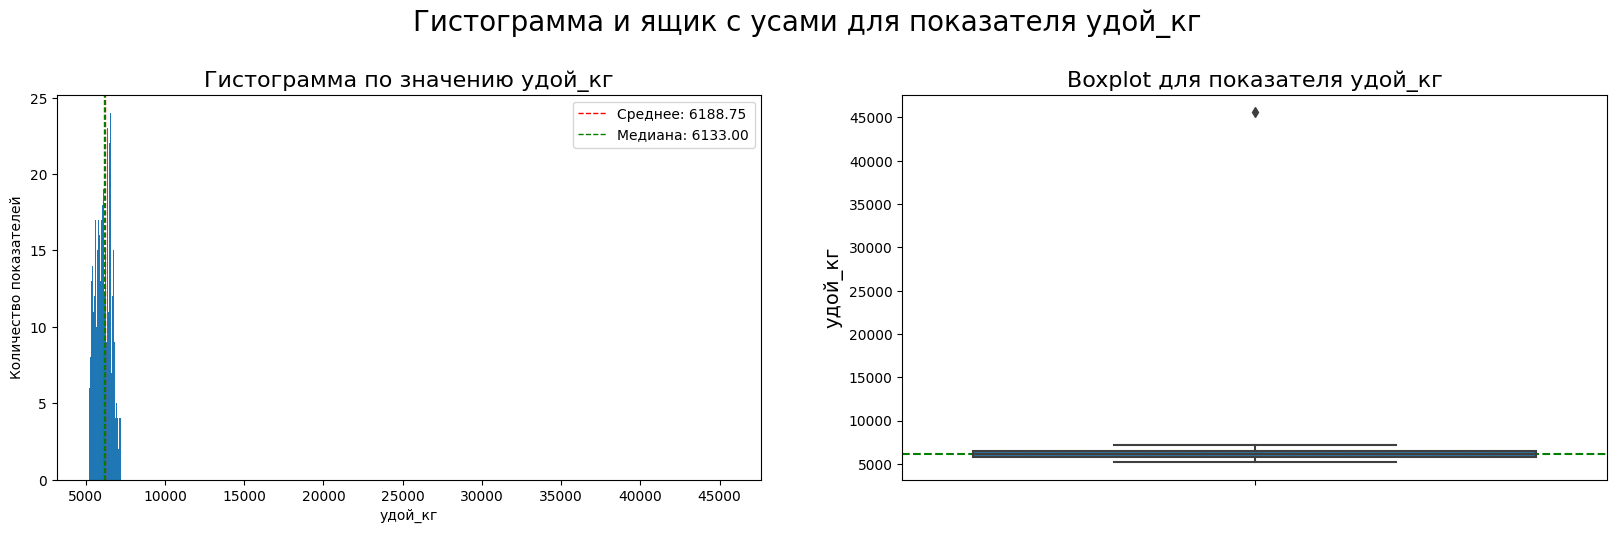

In [46]:
def hist_plot(data,index,bins):
    plt.figure(figsize=(20, 5))
    plt.suptitle('Гистограмма и ящик с усами для показателя ' + index, fontsize=20, y=1.05)
        
    
    plt.subplot(1, 2, 1)
    mean = np.mean(data[index])
    median = np.median(data[index])
    plt.hist(data[index],bins=bins)
    plt.axvline(mean, color='r', linestyle='dashed', linewidth=1, label=f'Среднее: {mean:.2f}')
    plt.axvline(median, color='g', linestyle='dashed', linewidth=1, label=f'Медиана: {median:.2f}');
    plt.ylabel('Количество показателей')
    plt.title('Гистограмма по значению ' + index, fontsize=16)
    plt.legend()
    plt.xlabel(index);
    
    plt.subplot(1, 2, 2)
    ax = sns.boxplot(y=index, data=data)
    plt.title('Boxplot для показателя ' + index, fontsize=16)
    plt.axhline(y=mean, color='g', linestyle='--')
    plt.ylabel(index, fontsize=14);
    plt.show()

hist_plot(ferma_main_dad,'удой_кг',1000)

Есть выброс по столбцу в размере 45616 кг. Вероятнее всего, это техническая ошибка. В реальных условиях необходимо было бы связаться с заказчиком и выяснить причину таких данных. В данном случае просто удалим эту строку.

In [47]:
ferma_main_dad = ferma_main_dad.query('удой_кг < 45616')

Аналогичное удаление сделаем и в датасете `ferma_main`. В дальнейшем нам с ним придется работать.

In [48]:
ferma_main = ferma_main.query('удой_кг < 45616')

In [49]:
ferma_main_dad.describe()

,id,удой_кг,эке,сырой_протеин_г,спо,жирность_%,белок_%
count,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000
mean,315.474522,6125.968153,14.548726,1923.759554,0.913089,3.604268,3.075670
std,181.475367,475.857053,1.301777,182.832816,0.032221,0.168093,0.002551
min,1.000000,5204.000000,10.900000,1660.000000,0.840000,2.990000,3.069000
25%,158.750000,5749.750000,13.500000,1771.750000,0.890000,3.590000,3.074000
50%,315.500000,6132.500000,14.700000,1888.000000,0.930000,3.650000,3.076000
75%,472.250000,6501.000000,15.600000,2062.250000,0.940000,3.720000,3.077000
max,629.000000,7222.000000,16.800000,2349.000000,0.960000,3.750000,3.085000


Выведем графики еще раз.

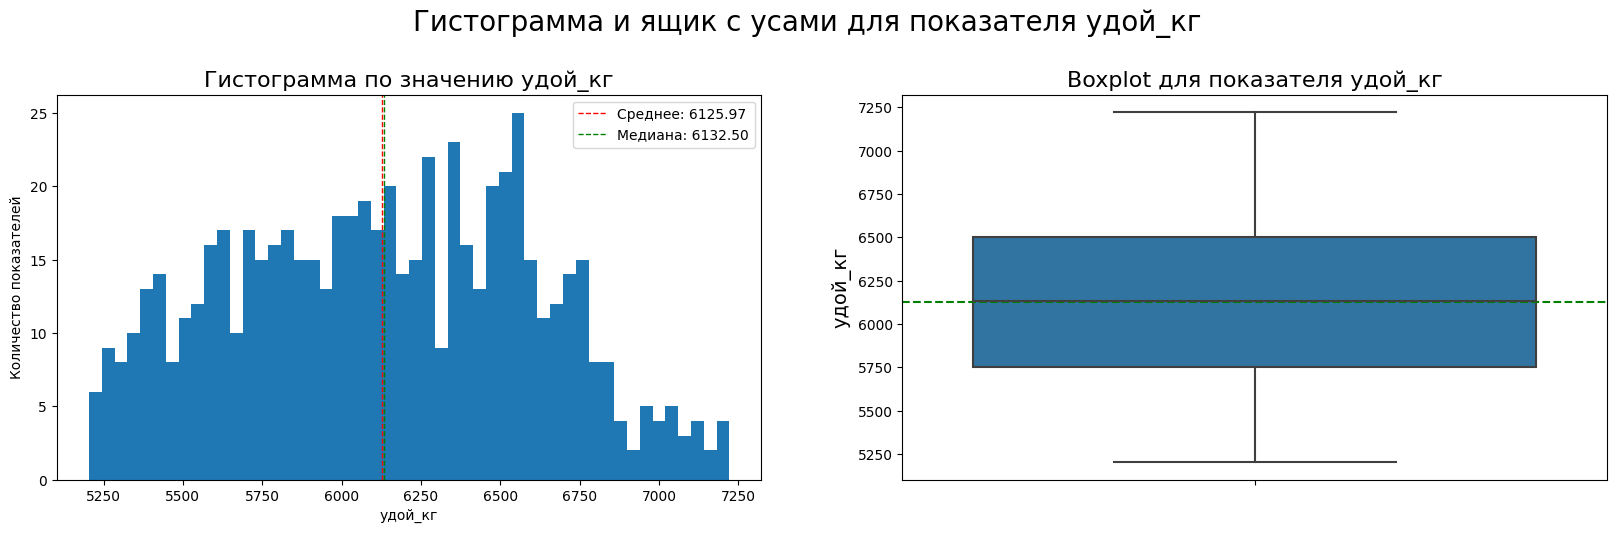

In [50]:
hist_plot(ferma_main_dad,'удой_кг',50)

**По показателю `удой_кг` показатели лежат в диапазоне 5204 – 7 222 кг/год на 1 корову. Выбивающееся значение 45 616 было удалено. В среднем по статистике надой молока на 1 корову в сутки составляет от 15 до 25 литров, что составляет 5 639 – 9399 кг в год. Среднее значение для датасета `ferma_main` составляет 6125,97 кг/год, а медиана - 6132,50 кг/год.**

### 3.1.2 Исследовательский анализ данных для 'ferma_main_dad' - 'эке'

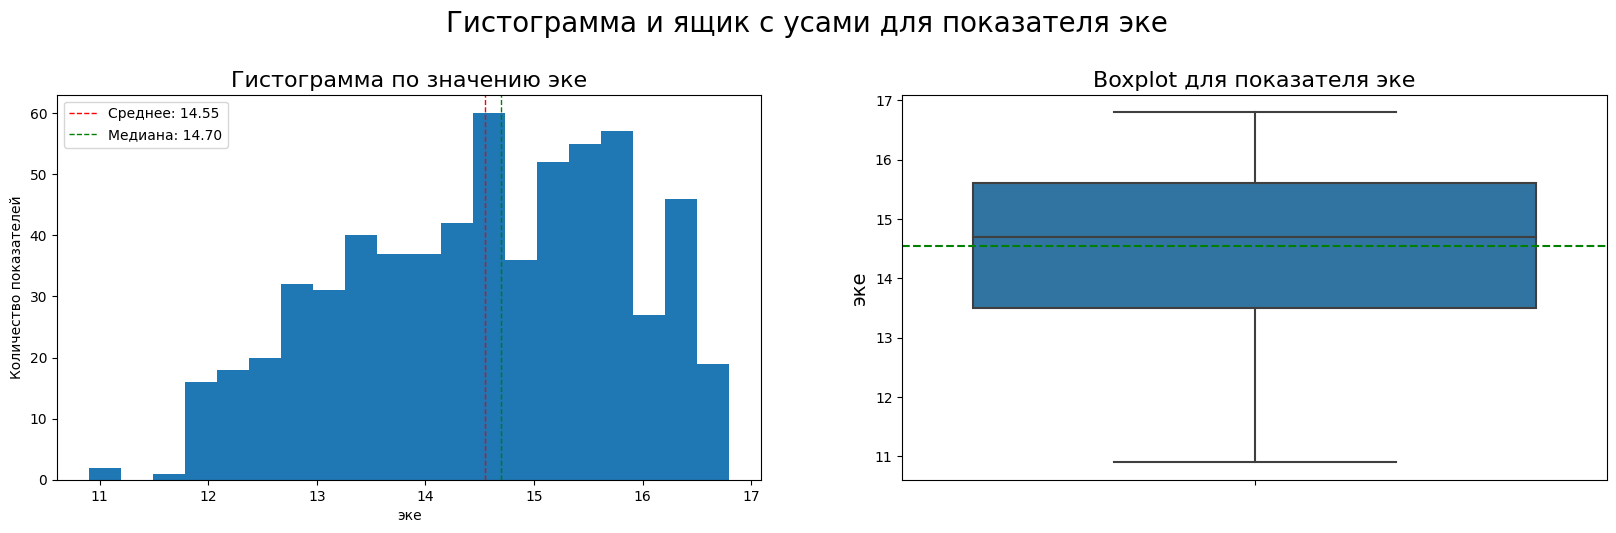

In [51]:
hist_plot(ferma_main_dad,'эке',20)

**По показателю `эке` показатели лежат в диапазоне 10,90 – 16,80. Среднее значение - 14,55, медиана - 14,70. Энергетическая кормовая единица (ЭКЕ) — показатель оценки питательности корма для животных. За одну ЭКЕ принято 10 МДж обменной энергии или 1 млн Дж. Показатель индивидуален для каждой коровы.**

### 3.1.3 Исследовательский анализ данных для 'ferma_main_dad' - 'сырой_протеин_г'

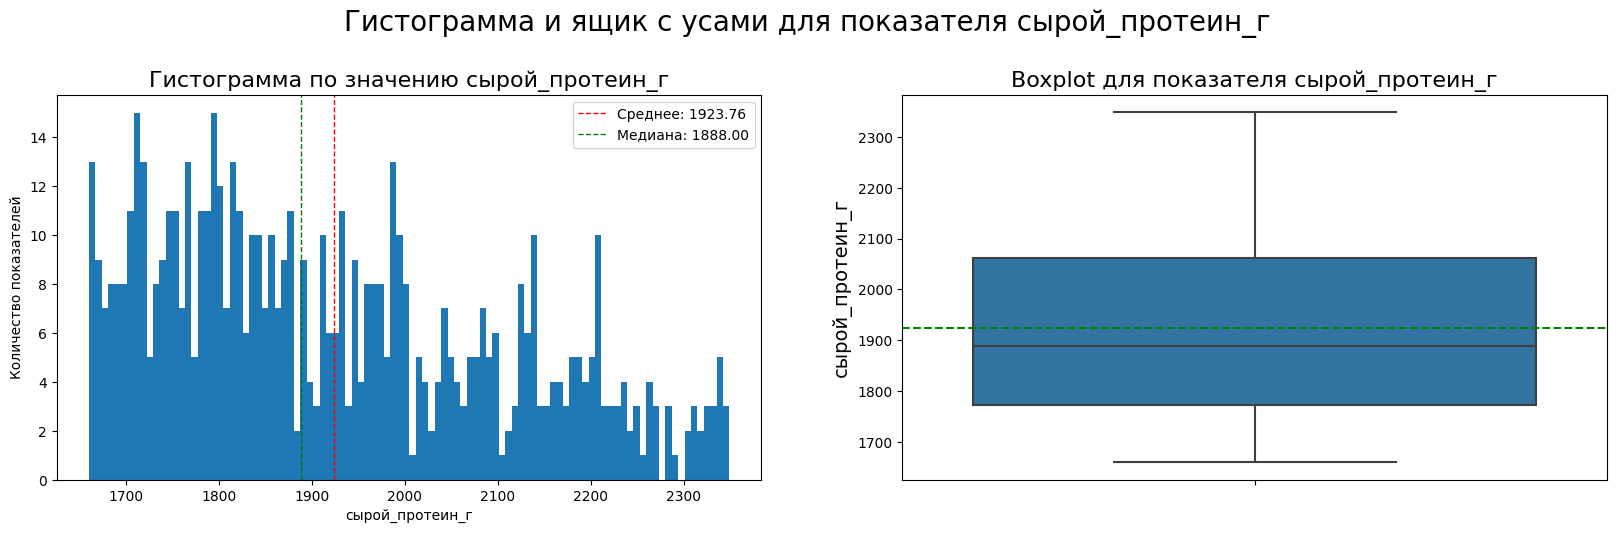

In [52]:
hist_plot(ferma_main_dad,'сырой_протеин_г',100)

**По показателю сырой_протеин_г показатели лежат в диапазоне 1660 – 2349. Среднее значение - 1923,76, медиана - 1888, 00. Показатель индивидуален для каждой коровы.**

### 3.1.4 Исследовательский анализ данных для 'ferma_main_dad' - 'спо'

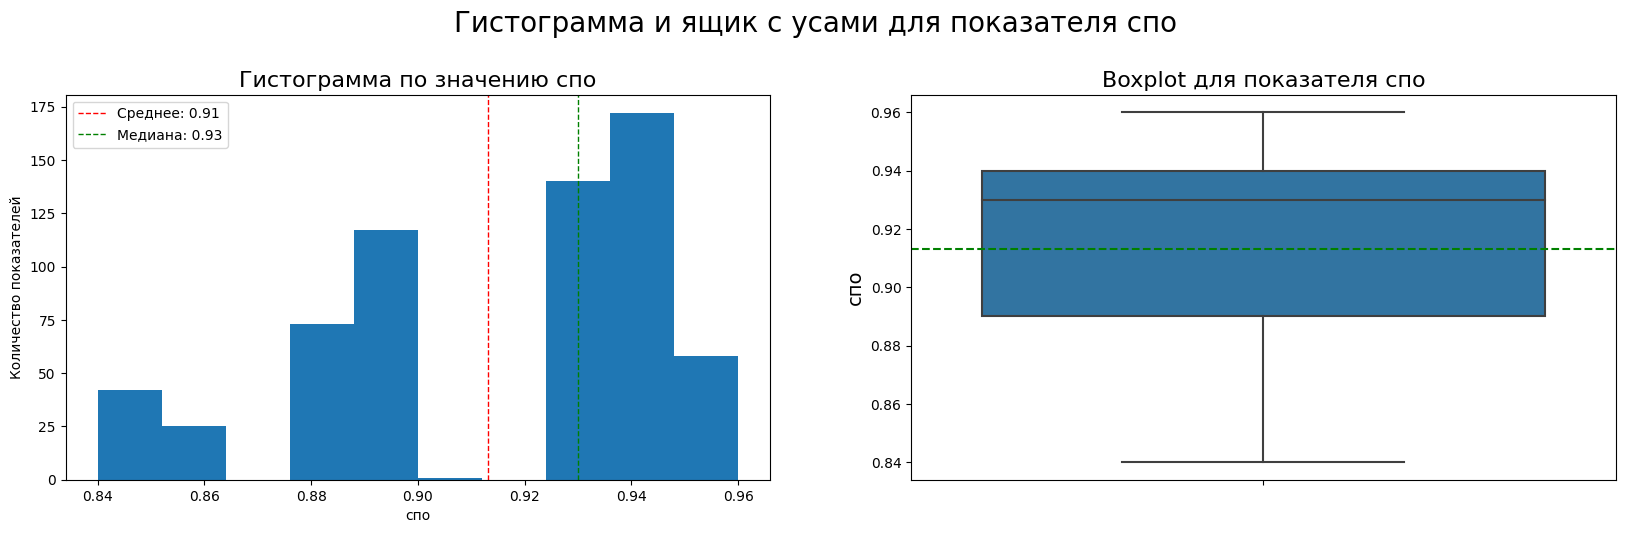

In [53]:
hist_plot(ferma_main_dad,'спо',10)

**По показателю `спо` показатели лежат в диапазоне 0,84 – 0,96. Среднее значение - 0,91, медиана - 0,93. В норме у крупного рогатого скота (КРС) сахаро-протеиновое отношение составляет 1:1, то есть на 1 грамм сахара приходится 1 грамм протеина. В рационах лактирующих коров сахаро-протеиновое отношение должно быть в пределах 0,8–1,1. Снижение этого показателя до 0,4–0,6 ухудшает использование питательных веществ и нарушает их обмен.**

### 3.1.5 Исследовательский анализ данных для 'ferma_main_dad' - 'порода'

,Количество
порода,
Вис Бик Айдиал,372
РефлешнСоверинг,256


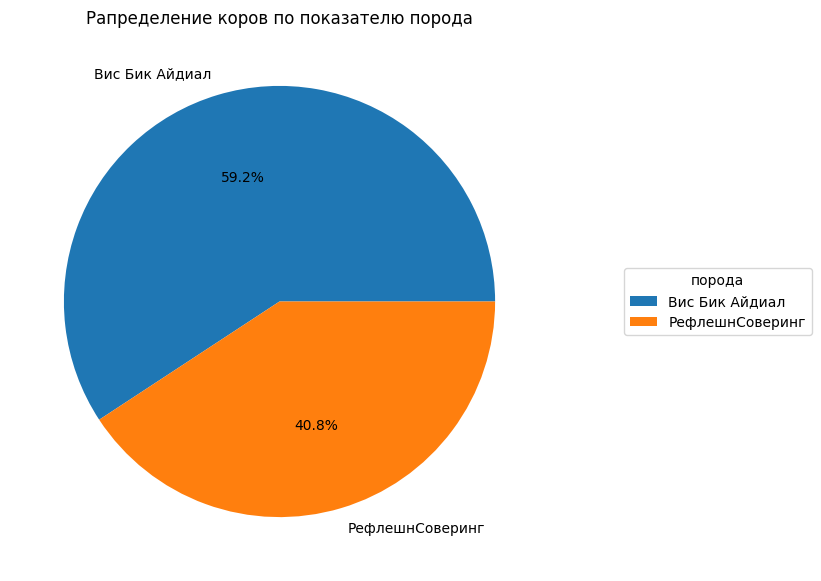

In [54]:
def pie_ferma(data,index,values):
    table = data.pivot_table(index=index, values=values, aggfunc='count')
    table.columns = ['Количество']
    display(table)
    ax = table.plot(kind='pie', y='Количество', autopct='%1.1f%%', figsize=(7,7));
    ax.legend(title=index, loc="center right", bbox_to_anchor = (1,0,0.5,1));
    plt.ylabel('');
    plt.title('Рапределение коров по показателю ' + index);
    
pie_ferma(ferma_main_dad, 'порода', 'id')

**По показателю порода 59,2% коров относятся к породе Вис Бик Айдиал и 40,8% - к породе РефлешнСоверинг.**

### 3.1.6 Исследовательский анализ данных для 'ferma_main_dad' - 'тип_пастбища'

,Количество
тип_пастбища,
Равнинное,278
Холмистое,350


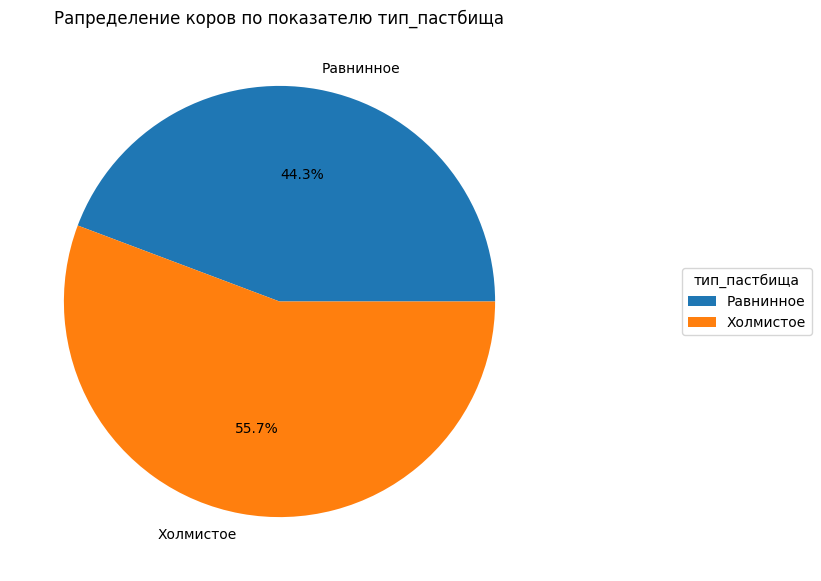

In [55]:
pie_ferma(ferma_main_dad, 'тип_пастбища', 'id')

**По показателю `тип_пастбища` 44,3% коров относятся к типу пастбища Равнинное и 55,7% - к типу Холмистое.**

### 3.1.7 Исследовательский анализ данных для 'ferma_main_dad' - 'порода_папы_быка'

,Количество
порода_папы_быка,
Айдиал,317
Соверин,311


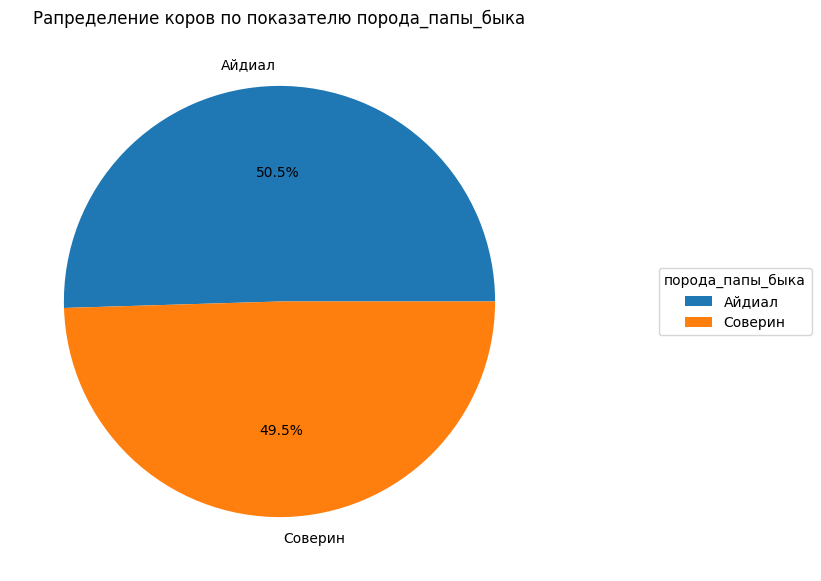

In [56]:
pie_ferma(ferma_main_dad, 'порода_папы_быка', 'id')

**По показателю порода_папы_быка 50,5% коров относятся к породе Айдиал и 49,5% - к породе Соверин.**

### 3.1.6 Исследовательский анализ данных для 'ferma_main_dad' - 'жирность_%'

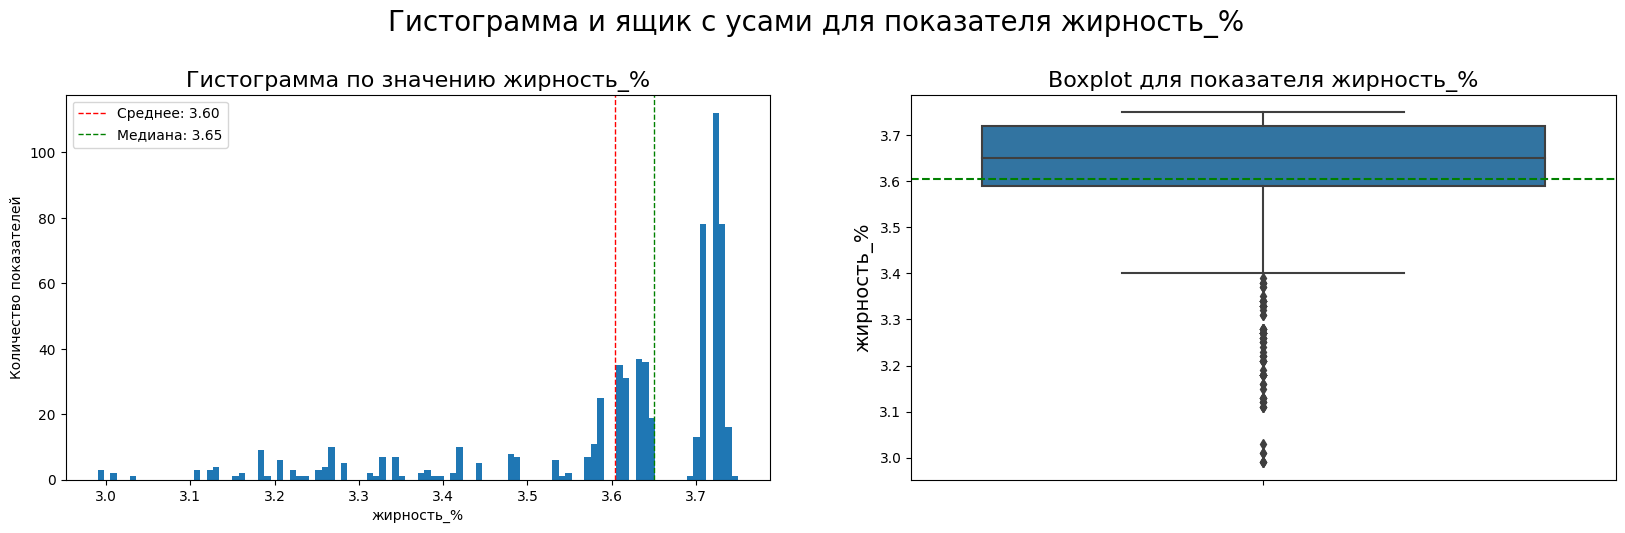

In [57]:
hist_plot(ferma_main_dad,'жирность_%',100)

**По показателю `жирность_%` показатели лежат в диапазоне 2,99 – 3,75%%. Среднее значение - 3,60%, медиана - 3,65%. Жирность молока у коровы может варьироваться от 0 до более 10%. Категории жирности молока: 0–1% — нежирное молоко для диетического питания; 1–2% — молоко с низким содержанием жира; около 3,5% — стандартная жирность свежего коровьего молока; от 4,5 до 6% — высокожирное молоко, характерное для определённых пород коров; 10% — категория сливок.**

### 3.1.7 Исследовательский анализ данных для 'ferma_main_dad' - 'белок_%'

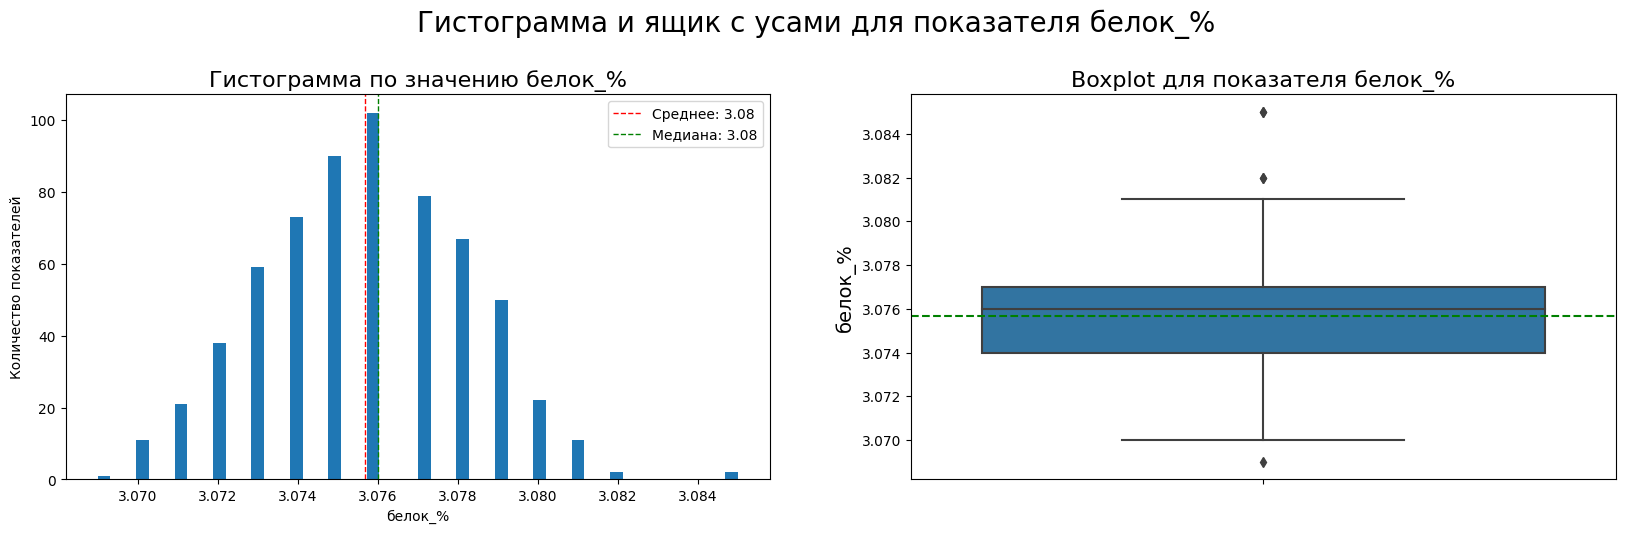

In [58]:
hist_plot(ferma_main_dad,'белок_%',50)

**По показателю белок_% показатели лежат в диапазоне 3,07 – 3,09%%. Среднее значение  - 3,08%, медиана - 3,08%. В цельном молоке коров в среднем содержится: белков – 3,2%.**

### 3.1.8 Исследовательский анализ данных для 'ferma_main_dad' - 'вкус_молока'

,Количество
вкус_молока,
вкусно,370
не вкусно,258


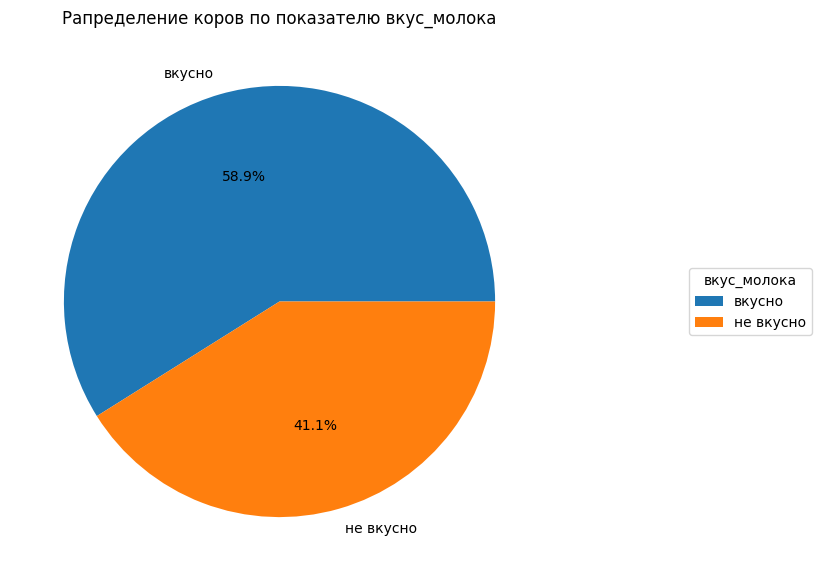

In [59]:
pie_ferma(ferma_main_dad, 'вкус_молока', 'id')

**По показателю `вкус_молока` 58,9% коров относятся к категории вкусно и 41,1% - к категории не вкусно.**

### 3.1.9 Исследовательский анализ данных для 'ferma_main_dad' - 'возраст'

,Количество
возраст,
более_2_лет,518
менее_2_лет,110


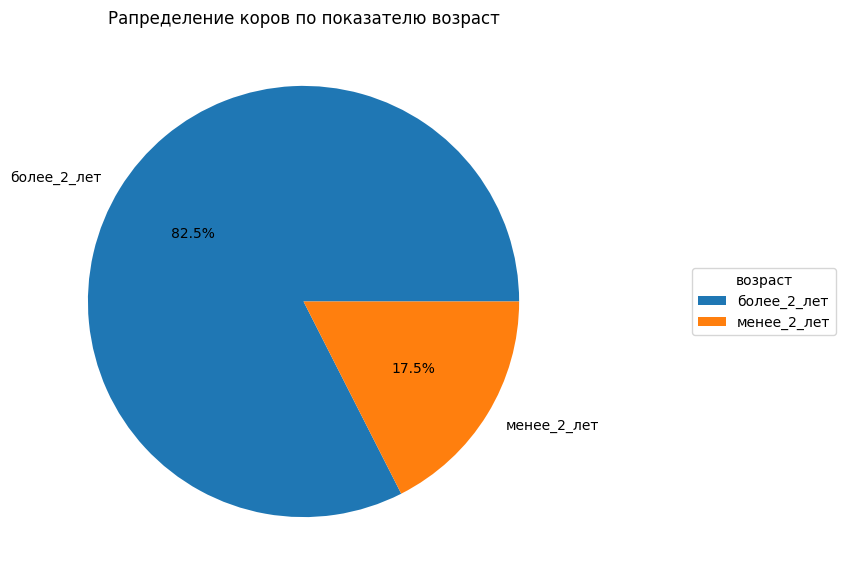

In [60]:
pie_ferma(ferma_main_dad, 'возраст', 'id')

**По показателю возраст 82,5% коров относятся к категории более 2 лет и 17,5% - к категории менее 2 лет.**

### 3.1.10 Исследовательский анализ данных для 'ferma_main_dad' - 'имя_папы'

,Количество
имя_папы,
Барин,240
Буйный,214
Геркулес,64
Соловчик,110


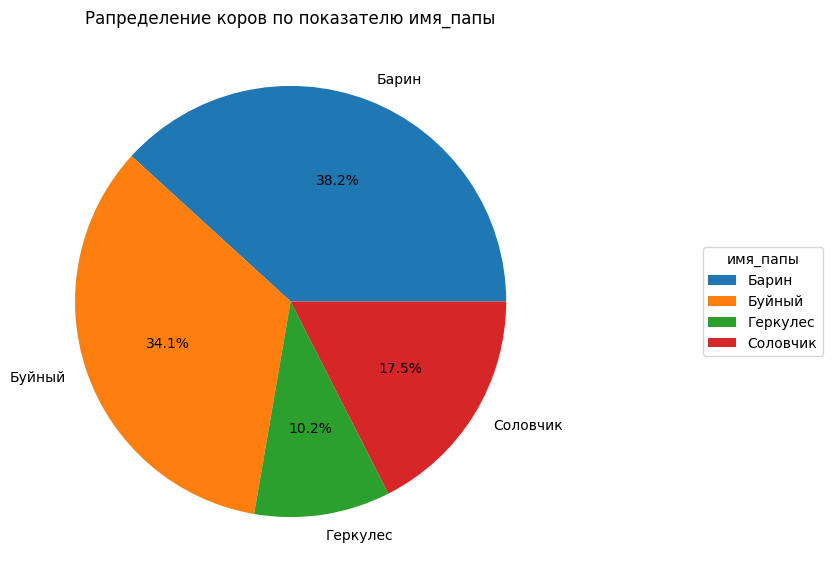

In [61]:
pie_ferma(ferma_main_dad, 'имя_папы', 'id')

**По показателю имя_папы 38,2% коров относятся к категории Барин, 34,1% - к категории Буйный, 17,5% - к категории Соловчик и 10,2% - к категории Геркулес.**

### 3.2 Исследовательский анализ данных для 'cow_buy'

In [62]:
cow_buy.describe()

,текущая_жирность_%,текущий_уровень_белок_%
count,16.000000,16.000000
mean,3.571875,3.068250
std,0.141620,0.011264
min,3.340000,3.046000
25%,3.415000,3.059500
50%,3.585000,3.073500
75%,3.692500,3.076750
max,3.770000,3.081000


### 3.2.1 Исследовательский анализ данных для 'cow_buy' - 'порода'

,Количество
порода,
Вис Бик Айдиал,8
РефлешнСоверинг,8


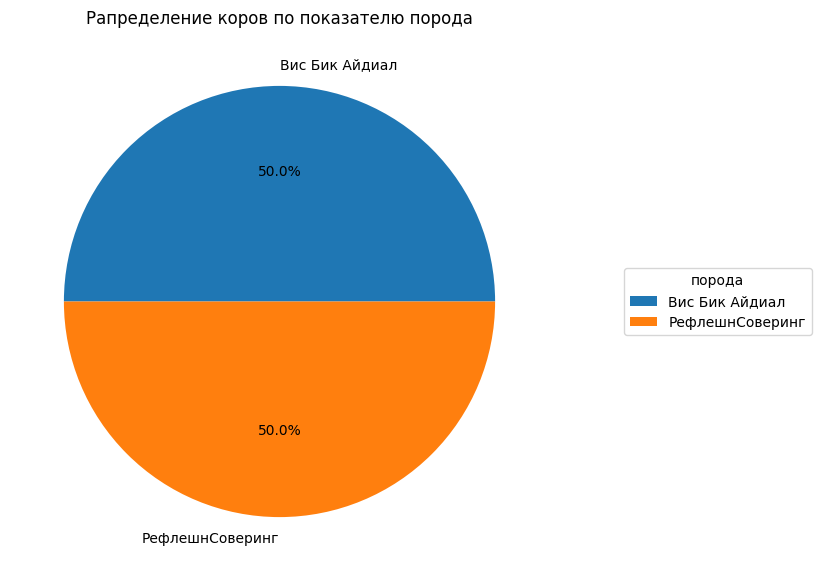

In [63]:
pie_ferma(cow_buy, 'порода', 'тип_пастбища')

**По показателю порода 50% коров относятся к породе Вис Бик Айдиал и 50% - к породе РефлешнСоверинг.**

### 3.2.2 Исследовательский анализ данных для 'cow_buy' - 'тип_пастбища'

,Количество
тип_пастбища,
Равнинное,8
Холмистое,8


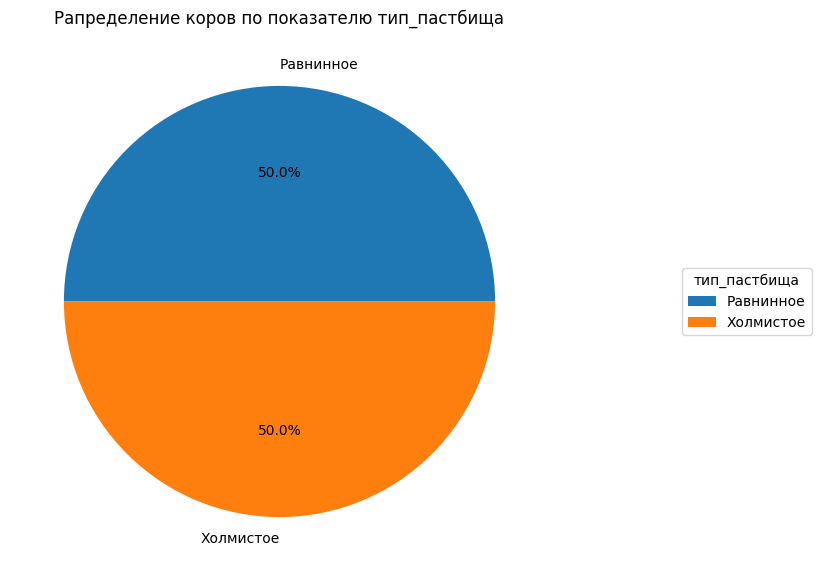

In [64]:
pie_ferma(cow_buy, 'тип_пастбища', 'порода')

**По показателю тип_пастбища 50% коров относятся к типу пастбища Равнинное и 40% - к типу Холмистое.**

### 3.2.3 Исследовательский анализ данных для 'cow_buy' - 'порода_папы_быка'

,Количество
порода_папы_быка,
Айдиал,6
Соверин,10


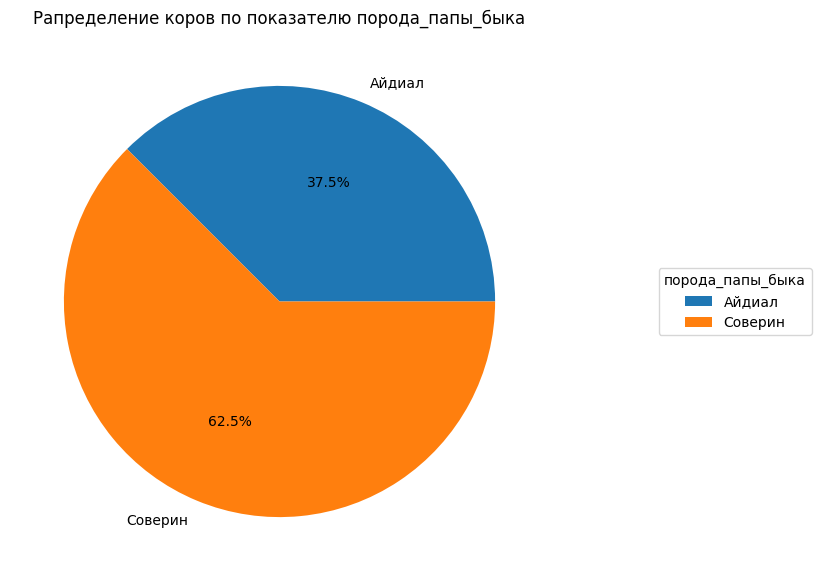

In [65]:
pie_ferma(cow_buy, 'порода_папы_быка', 'порода')

**По показателю порода_папы_быка 37,5% коров относятся к породе Айдиал и 62,5% - к породе Соверин.**

### 3.2.4 Исследовательский анализ данных для 'cow_buy' - 'имя_папы'

,Количество
имя_папы,
Барин,2
Буйный,7
Геркулес,5
Соловчик,2


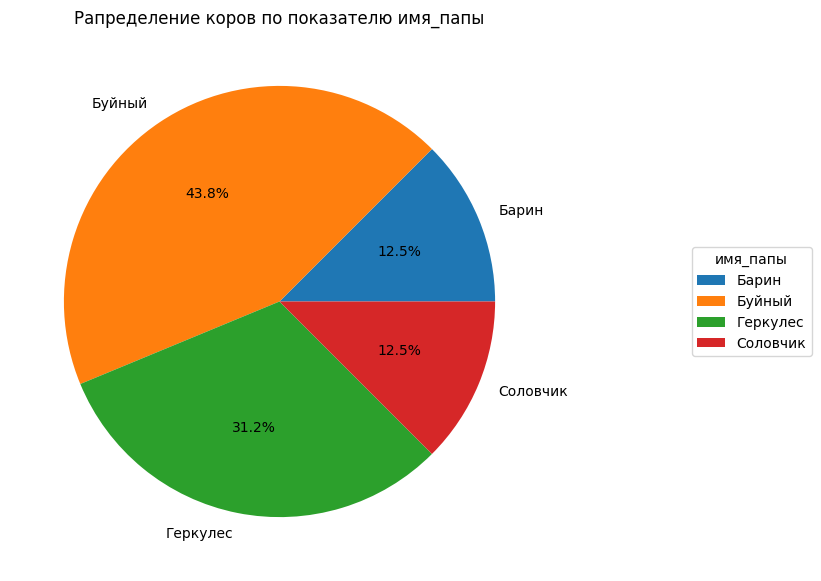

In [66]:
pie_ferma(cow_buy, 'имя_папы', 'порода')

**По показателю имя_папы 43,8% коров относятся к категории Буйный, 31,2% - к категории Геркулес, 12,5% - к категории Барин и 12,5% - к категории Соловчик.**

### 3.2.5 Исследовательский анализ данных для 'cow_buy' - 'текущая _ жирность _ %'

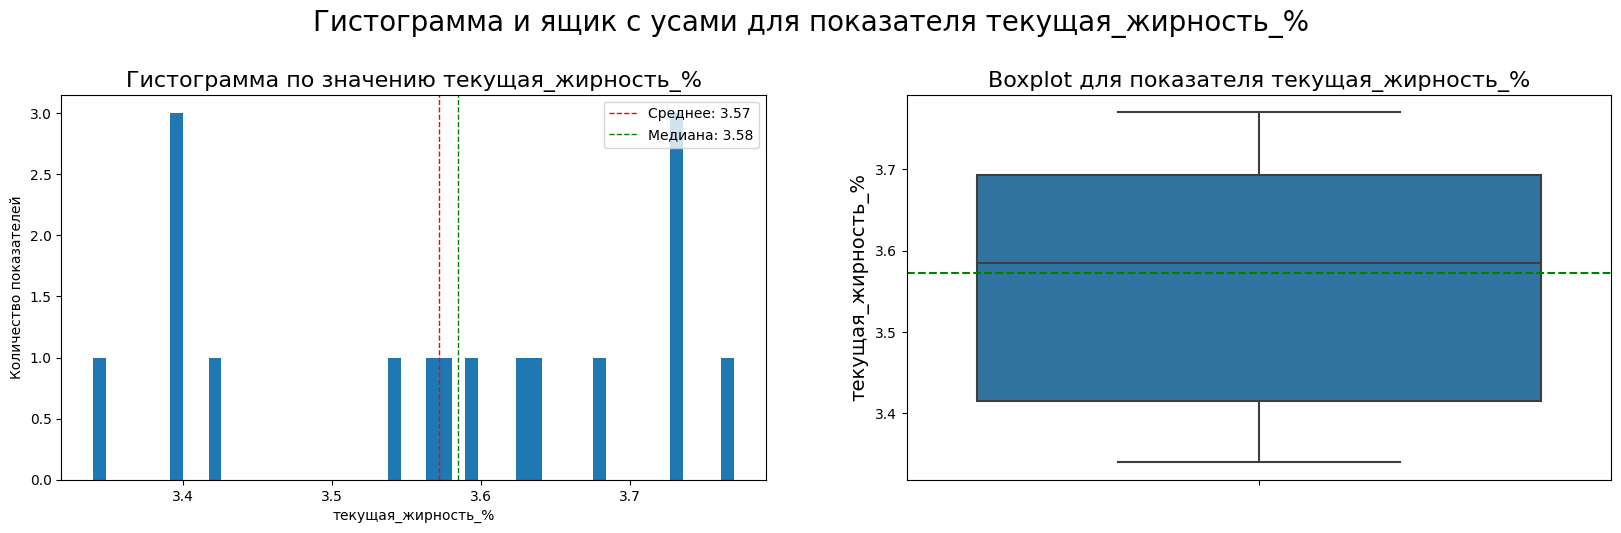

In [67]:
hist_plot(cow_buy,'текущая_жирность_%',50)

**По показателю `текущая_жирность_%` показатели лежат в диапазоне 3,34 – 3,77%. Среднее значение - 3,57%, медиана - 3,58%.**

### 3.2.6 Исследовательский анализ данных для 'cow_buy' - 'текущий _ уровень _ белок_%'

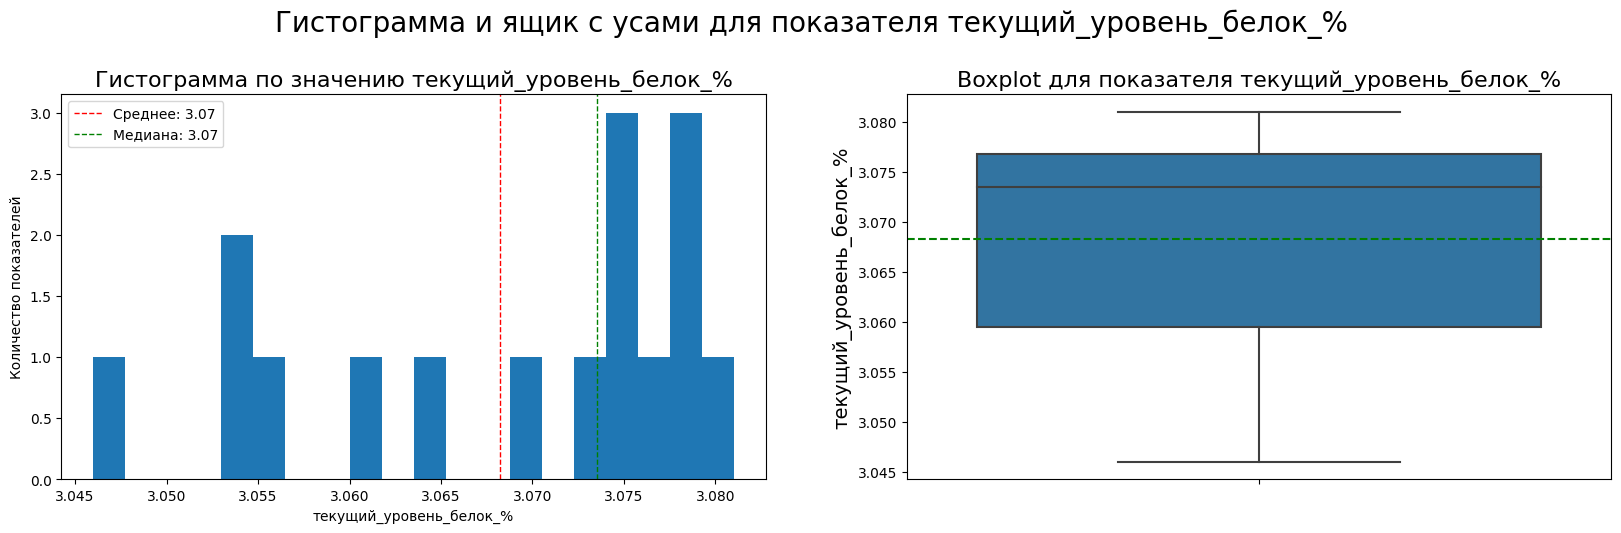

In [68]:
hist_plot(cow_buy,'текущий_уровень_белок_%',20)

**По показателю `текущий_уровень_белок_%` показатели лежат в диапазоне 3,05 – 3,08%. Среднее значение - 3,07%, медиана - 3,07%.**

### 3.2.7 Исследовательский анализ данных для 'cow_buy' - 'возраст'

,Количество
возраст,
более_2_лет,11
менее_2_лет,5


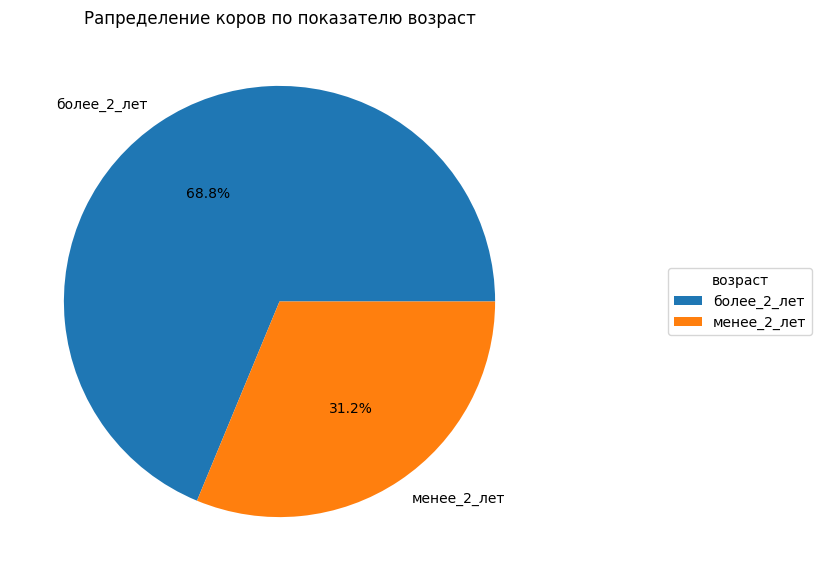

In [69]:
pie_ferma(cow_buy, 'возраст', 'порода')

**По показателю `возраст` 68,8% коров относятся к категории более 2 лет и 31,2% - к категории менее 2 лет.**

<div style="border:solid green 2px; padding: 20px">
Вывод: На шаге 3 был проведен исследовательский анализ данных. были построены соответствующие графики для каждого признака. Как таковых выбросов замечено не было. Все показатели в пределах статистической рыночной нормы. 
    
Улучшение данных возможно при уточнении данных у заказчика и поставщика, что возможно в реальном проекте.

## Шаг 4. Корреляционный анализ

### 4.1 Изучение взаимосвязи между признаками для датасета `ferma_main`. Расчет коэффициентов корреляции между всеми признаками

Так как мы уже объединили два датасета `ferma_main` и `ferma_dad`, а также внесли корректировку в один из показателей `удой_кг`, то в данном случае ориентироваться на датасет `ferma_main_dad`

In [70]:
display(ferma_main_dad.drop(['порода',
                             'тип_пастбища',
                             'порода_папы_быка',
                             'вкус_молока',
                             'возраст',
                             'имя_папы'], axis=1).corr())

,id,удой_кг,эке,сырой_протеин_г,спо,жирность_%,белок_%
id,1.000000,-0.006816,-0.028600,-0.035613,-0.064803,0.017126,0.002547
удой_кг,-0.006816,1.000000,0.765098,0.446731,0.806339,0.600902,0.002966
эке,-0.028600,0.765098,1.000000,0.387875,0.749007,0.637279,-0.008939
сырой_протеин_г,-0.035613,0.446731,0.387875,1.000000,0.446332,0.357793,0.226802
спо,-0.064803,0.806339,0.749007,0.446332,1.000000,0.629098,0.073718
жирность_%,0.017126,0.600902,0.637279,0.357793,0.629098,1.000000,-0.026542
белок_%,0.002547,0.002966,-0.008939,0.226802,0.073718,-0.026542,1.000000


In [71]:
display(ferma_main)

,id,удой_кг,эке,сырой_протеин_г,спо,порода,тип_пастбища,порода_папы_быка,жирность_%,белок_%,вкус_молока,возраст
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет
...,...,...,...,...,...,...,...,...,...,...,...,...
624,625,6812,15.4,1964,0.940,РефлешнСоверинг,Равнинное,Айдиал,3.74,3.075,не вкусно,более_2_лет
625,626,5513,12.9,1700,0.880,РефлешнСоверинг,Равнинное,Соверин,3.64,3.073,вкусно,менее_2_лет
626,627,5970,14.4,1837,0.880,РефлешнСоверинг,Холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
627,628,5746,13.8,1994,0.890,РефлешнСоверинг,Равнинное,Соверин,3.64,3.077,вкусно,более_2_лет


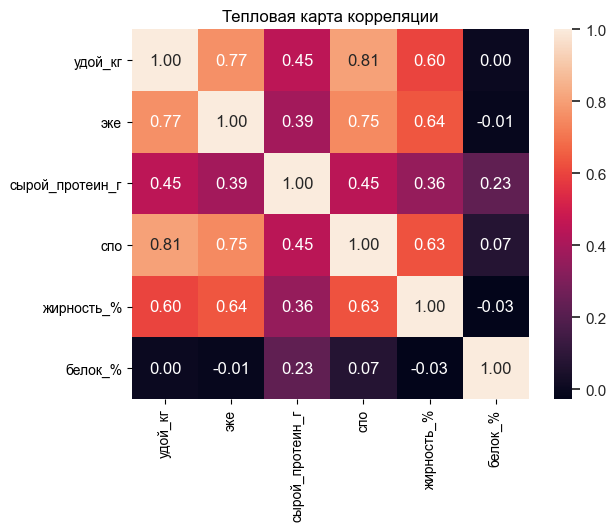

In [72]:
ax = plt.axes()
sns.set(rc={"figure.figsize": (5, 5)})
sns.heatmap(ferma_main.drop(['порода',
                             'тип_пастбища',
                             'порода_папы_быка',
                             'вкус_молока',
                             'возраст',
                             'id'], axis=1).corr(), annot=True, fmt='.2f')
ax.set_title('Тепловая карта корреляции');

Проанализированы данные корреляции. Ниже представлена таблица коэффициентов корреляции (шкала Чеддока):

| Значение       | Интерпретация  |
|:--------------:|:--------------:|
| от 0 до 0,3    | очень слабая   |
| от 0,3 до 0,5  | слабая         |
| от 0, 5 до 0,7 | средняя        |
| от 0,7 до 0,9 | высокая        |
| от 0,9 до 1    | очень высокая  |

Таким образом, средняя и высокая взаимосвязь наблюдается у интересующего нас показателя `удой_кг` с показателями `эке`, `спо` и `жирность_%`

### 4.2 Построение диаграммы рассеяния scatterplot для признака `удой_кг` и всех количественных признаков с учётом значения категориальных признаков

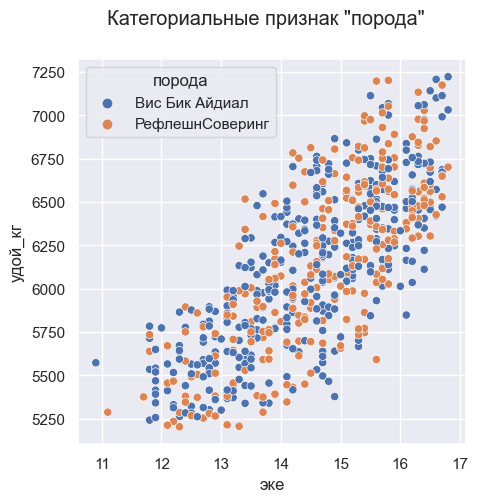

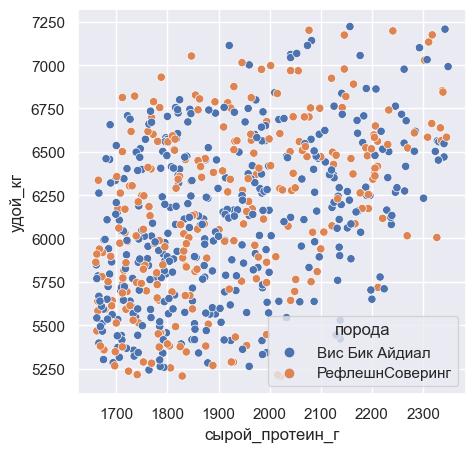

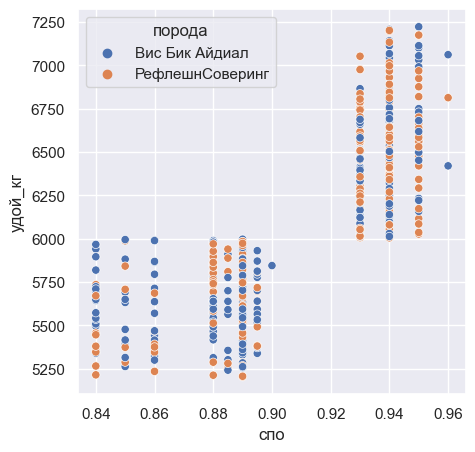

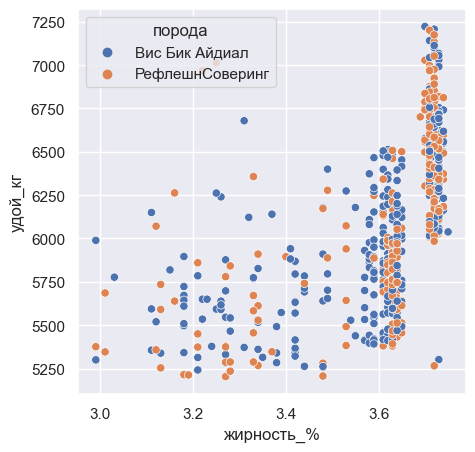

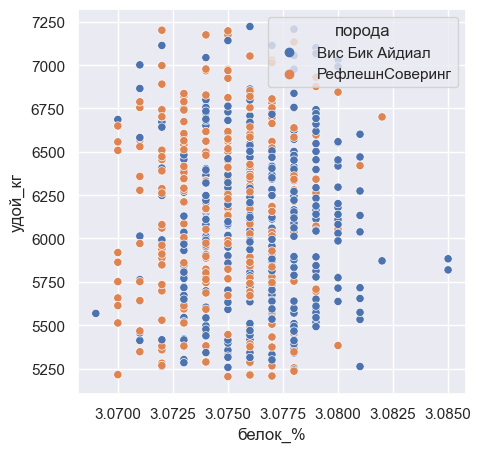

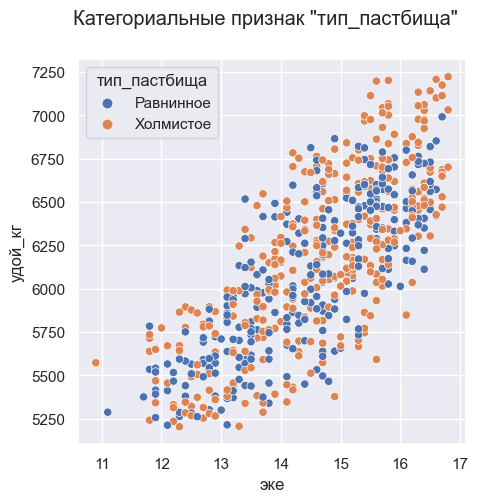

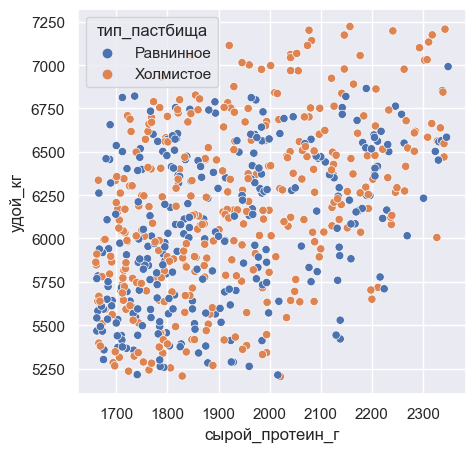

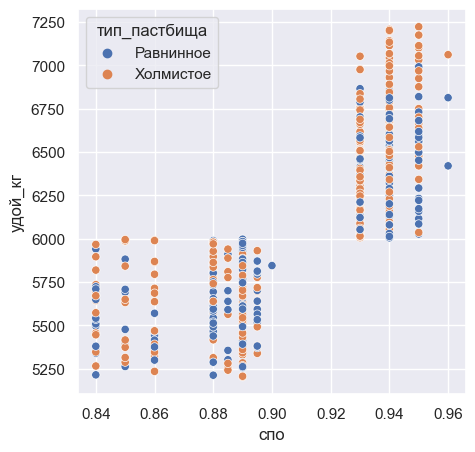

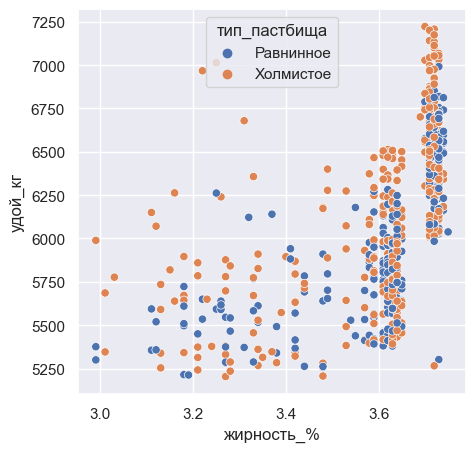

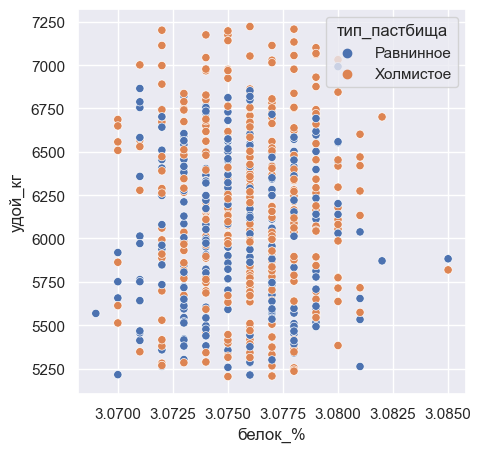

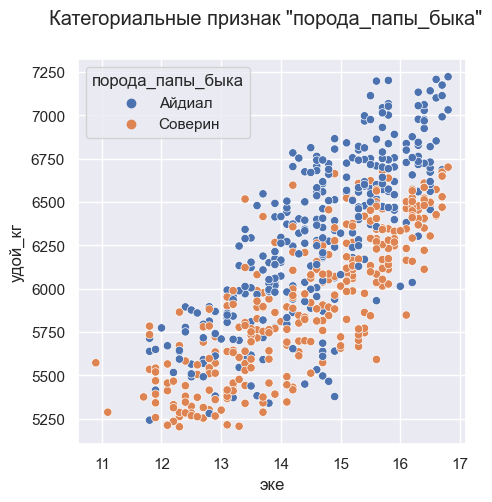

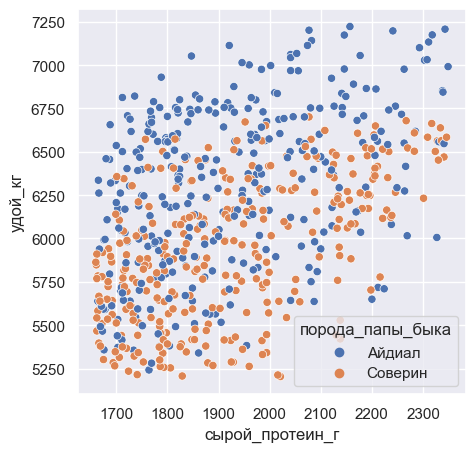

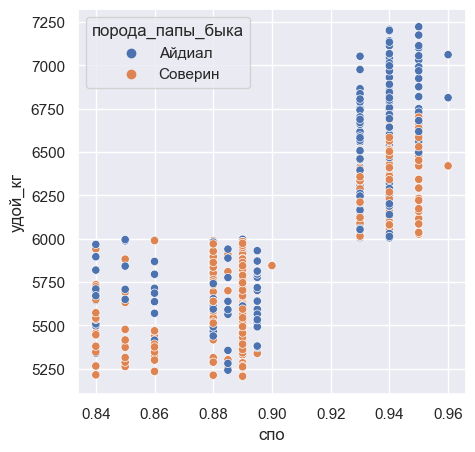

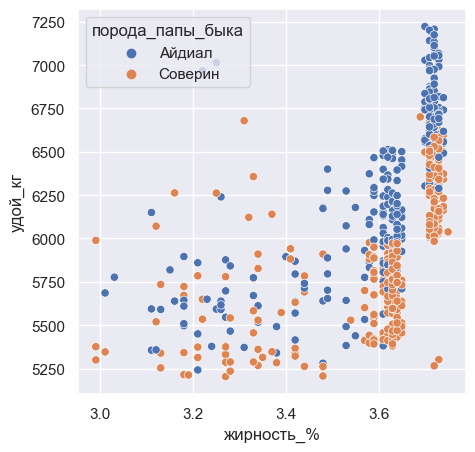

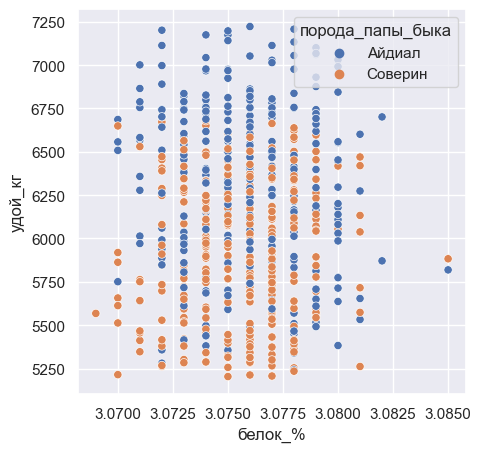

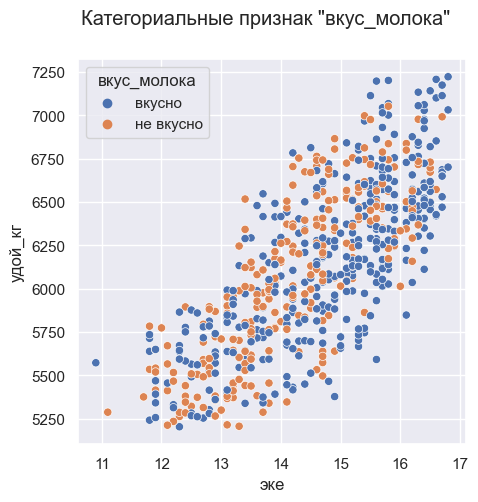

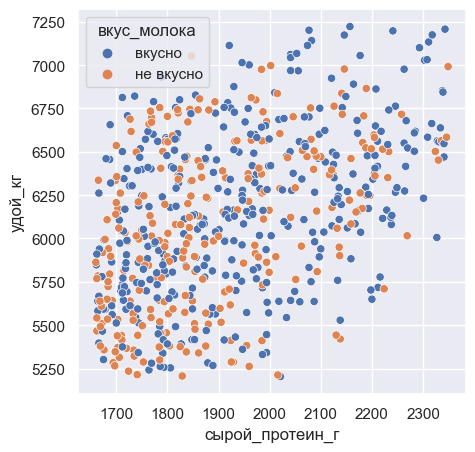

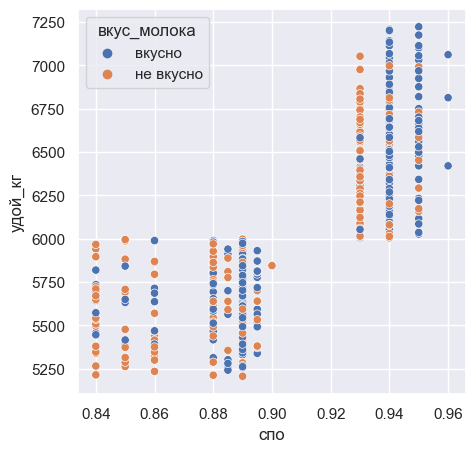

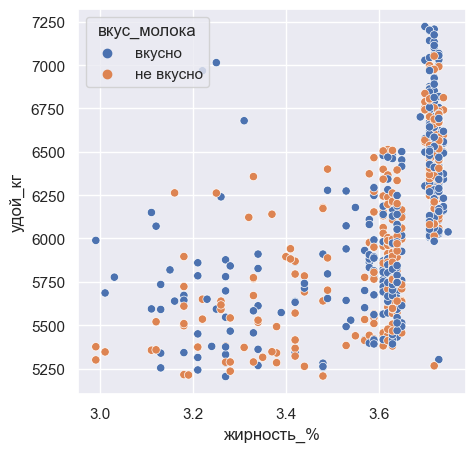

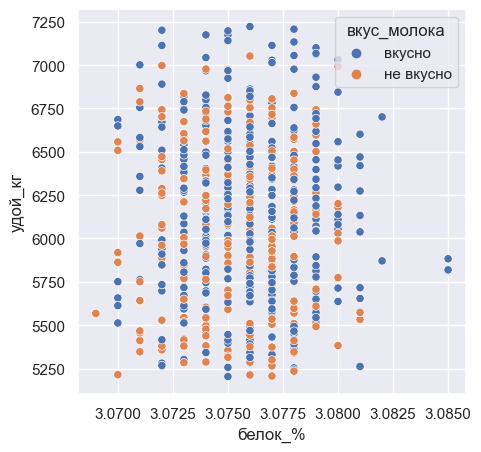

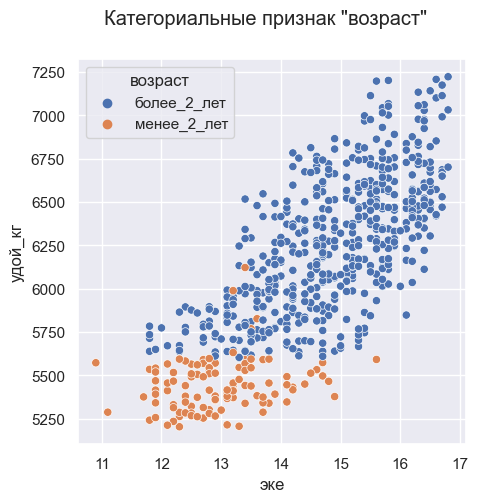

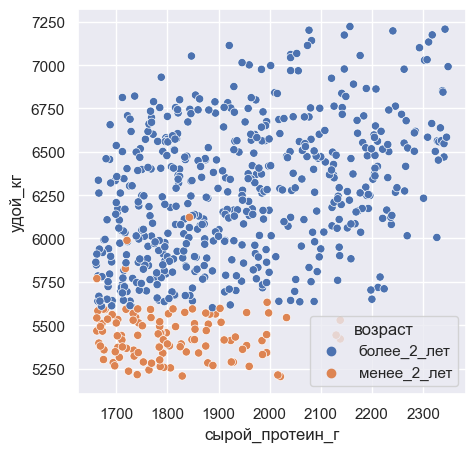

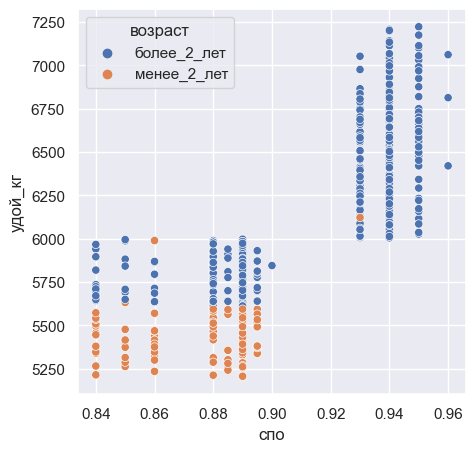

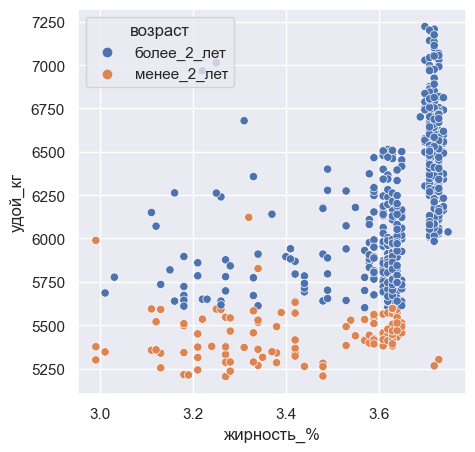

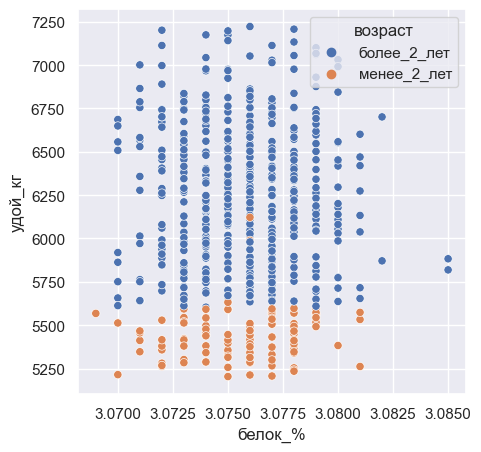

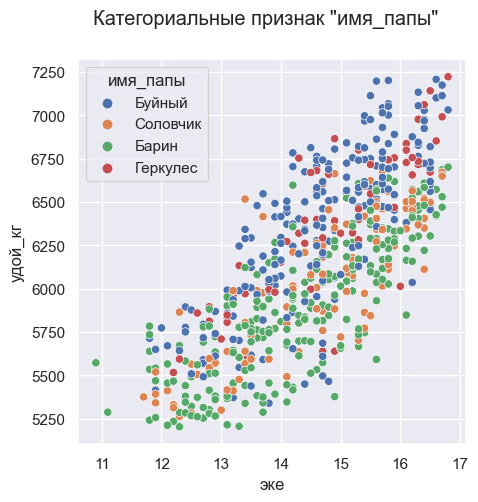

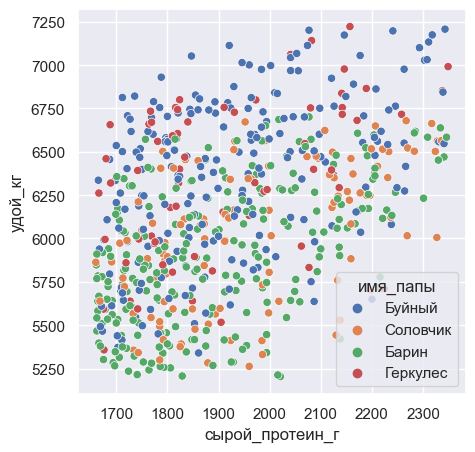

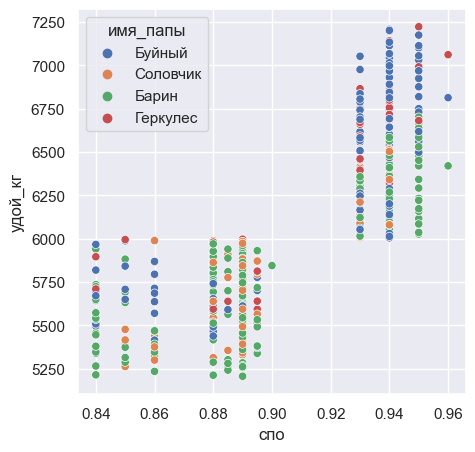

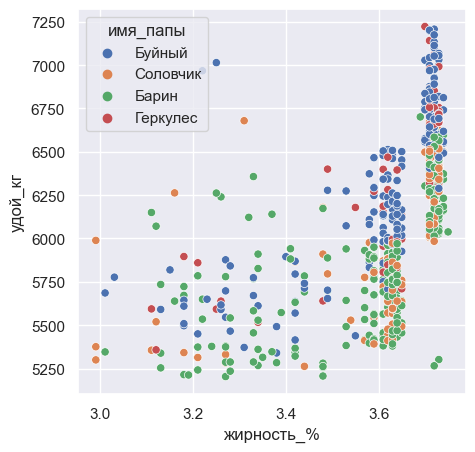

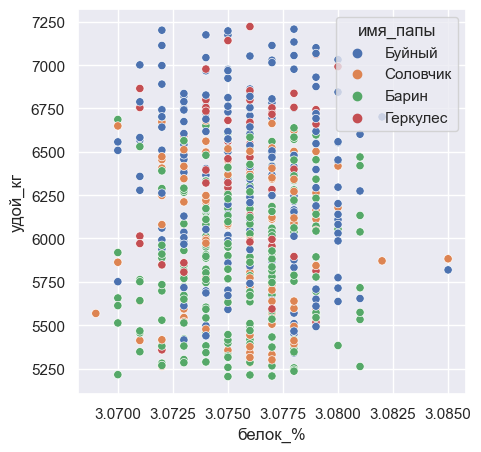

In [73]:
list = ['эке','сырой_протеин_г','спо','жирность_%','белок_%']

def diag_chart(ferma_main_dad, parametr = 'порода'): 
    
    fig, axs = plt.subplots(figsize=(5, 5))
    if parametr == 'порода':            
        fig.suptitle('Категориальные признак "порода"')
    elif parametr == 'тип_пастбища':             
        fig.suptitle('Категориальные признак "тип_пастбища"')
    elif parametr == 'порода_папы_быка':            
        fig.suptitle('Категориальные признак "порода_папы_быка"')
    elif parametr=='вкус_молока':
        fig.suptitle('Категориальные признак "вкус_молока"')
    elif parametr=='возраст':
        fig.suptitle('Категориальные признак "возраст"')
    elif parametr=='имя_папы':
        fig.suptitle('Категориальные признак "имя_папы"')
    for r in list:
        sns.scatterplot(data=ferma_main_dad, x=r, y='удой_кг', hue=parametr)
        plt.show()
    
diag_chart(ferma_main_dad, 'порода')          
diag_chart(ferma_main_dad, 'тип_пастбища')
diag_chart(ferma_main_dad, 'порода_папы_быка')
diag_chart(ferma_main_dad, 'вкус_молока')
diag_chart(ferma_main_dad, 'возраст')
diag_chart(ferma_main_dad, 'имя_папы')                  

<div style="border:solid green 2px; padding: 20px">
Вывод: На шаге 4 был проведен корреляционный анализ признаков.
    
Основной датасет `ferma_main_dad` был разделен на 4 части по типу пастбища и породе коровы.
    
Взаимосвязь между целевым и входными признаками может быть представлена корреляционной связью. Она отражает тот факт, что изменчивость одного признака находится в некотором соответствии с изменчивостью другого.
    
Наблюдается линейная связь между показателями `удой_кг` и `эке`. Между показателем `удой_кг` и остальными входными признаками скорее нелинейная связь, но новые данные вводить не надо, т.к. основные представленные входные признаки уже представляют большинство показателей, от которых зависит качество удоя и на их основании можно провести дальнейшую работу.
    
Мультиколлинеарность между **входными признаками** не наблюдается.
    


## Шаг 5. Обучение модели линейной регрессии

### 5.1 Подготовка данных датасета 'ferma_main.csv' и обучение на них первой модели 'LinearRegression'

В качестве входных признаков отобраны:
    
- эке
- сырой_протеин_г
- спо
- порода
- тип_пастбища
- порода_папы_быка
- возраст

Они оказывают влияние на удой. Это состав корма (в том числе и тип пастбища), порода коровы и папы-быка, возраст. Остальные признаки относятся скорее к последствиям вместе с удоем (вкус и состав молока). Показатель `id` не влияет ни на что. Это по сути идентификатор лактационной коровы.

In [74]:
def r2_func(data, col_X, cat_col_names, num_col_names):
    global predictions,y_test
        
    X = data.drop(col_X, axis=1)
    y = data['удой_кг']

    # разбивка данных на тренировочную и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, 
        y, 
        random_state=RANDOM_STATE)

    cat_col_names = cat_col_names
    num_col_names = num_col_names

    ## подготовка признаков (масштабирование и кодирование)

    encoder = OneHotEncoder(drop='first', sparse=False)
    X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
    X_test_ohe = encoder.transform(X_test[cat_col_names])

    encoder_col_names = encoder.get_feature_names()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[num_col_names])
    X_test_scaled = scaler.transform(X_test[num_col_names])

    X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
    X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

    X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
    X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

    # инициализирование модели линейной регрессии
    model_lr  = LinearRegression()

    # обучение модели на тренировочных данных
    model_lr.fit(X_train, y_train)

    # получение предсказания модели на тестовых данных 
    # сохранение результата в переменную predictions
    predictions = model_lr.predict(X_test)

D:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


R2 LinearRegression = 0.7844078173416966


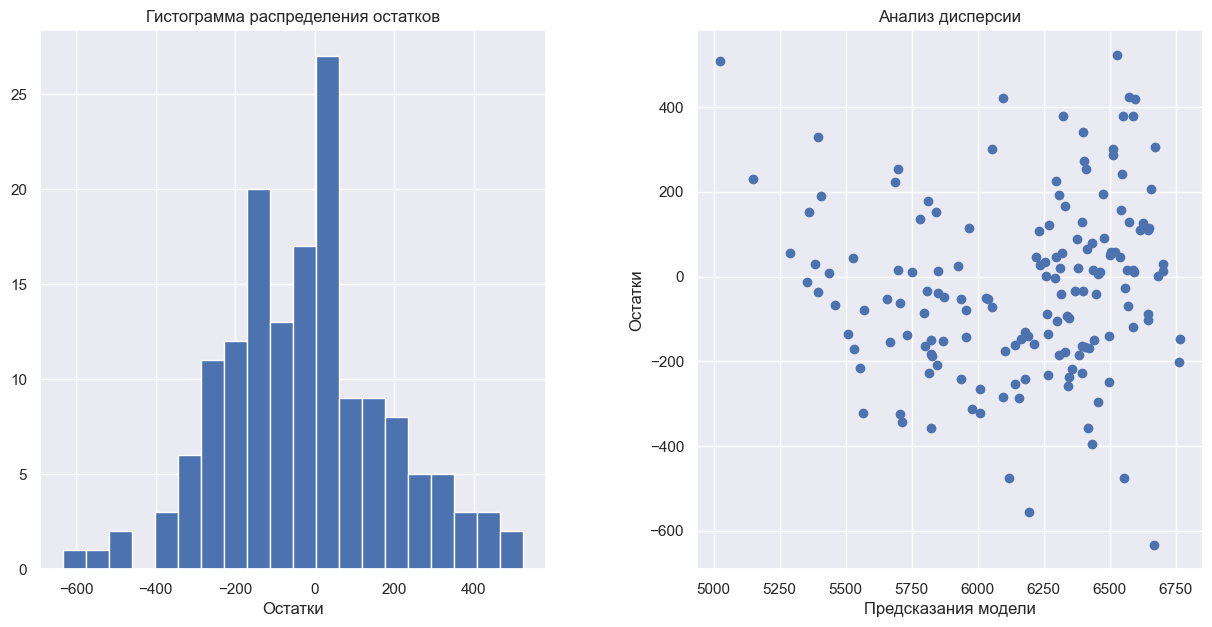

In [75]:
def graf_r2(func):
    r2_func(data, col_X, cat_col_names, num_col_names)
    # расчет значения R2 для линейной регрессии
    
    r2 = r2_score(y_test, predictions)

    # вывод полученного значения R2
    print("R2 LinearRegression =", r2)

    # проведение анализа остатков
    residuals = y_test - predictions

    # построение графиков по количественным признакам — гистограмму частотности 
    # распределения и диаграмму рассеяния
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,7))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    axes[0].hist(residuals, bins = 20)
    axes[0].set_title('Гистограмма распределения остатков')
    axes[0].set_xlabel('Остатки')

    axes[1].scatter(predictions,residuals)
    axes[1].set_xlabel('Предсказания модели')
    axes[1].set_ylabel('Остатки')
    axes[1].set_title('Анализ дисперсии')
    plt.show()
    
num_col_names = ['эке', 'сырой_протеин_г', 'спо']
cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'возраст']
col_X = ['id', 'удой_кг', 'жирность_%', 'белок_%', 'вкус_молока']
data = ferma_main
graf_r2(r2_func)

**Несмотря на достаточно высокое значение R<sup>2</sup> модель согласно методу остатков не очень хорошо работает. Диаграмма рассеяния показывает нелинейно распределённые остатки. Маленькая и большая дисперсии остатков чередуются на графике. Гистограмма показывает сдвиг вправо.**

### 5.2 Подготовка данных с учётом связи входных признаков с целевым и обучение на них второй модели LinearRegression

D:\Anaconda\envs\practicum\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


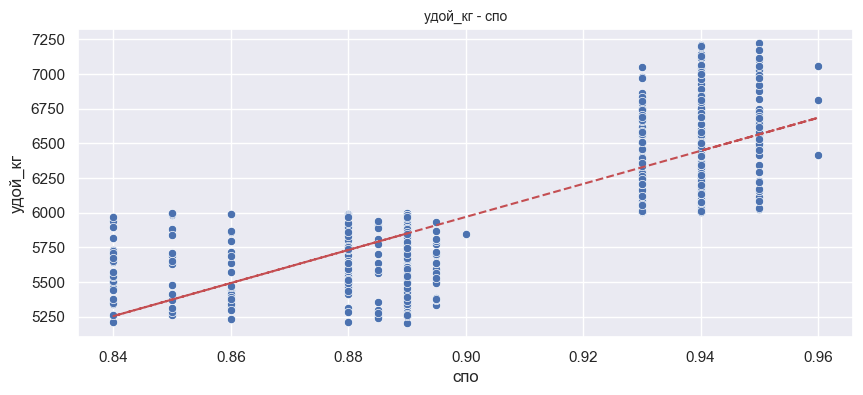

In [76]:
fig, axs = plt.subplots(figsize=(10, 4))
plt.title('удой_кг - спо', fontsize=10)
x = ferma_main['спо']
y = ferma_main['удой_кг']
sns.scatterplot(x, y, data=ferma_main)
plt.ylabel('удой_кг')
plt.xlabel('спо')

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x,p(x),"r--")
plt.show()

Обнаружено, что `спо` и `удой_кг` связаны нелинейно. На их диаграмме рассеяния наблюдения сгруппированы в два кластера, причём есть такое значение `спо`, которое можно считать границей между кластерами. Чтобы устранить нелинейность, преобразуем СПО в категориальный бинарный признак, использовав эту границу.

Границей кластера можно считать значение 0,91.

In [77]:
ferma_main['класс_спо'] = ferma_main['спо'].apply(lambda x: 1 if x > 0.91 else 0)

In [78]:
ferma_spo_class = pd.pivot_table(ferma_main, index='класс_спо', values = ['id'], aggfunc='count')
ferma_spo_class.columns = ['Количество']
display(ferma_spo_class)

,Количество
класс_спо,
0,258
1,370


Обнаружено, что `эке` и `удой_кг` также связаны нелинейно. Нелинейность между ними можно исключить, если ввести новый признак ЭКЕ в квадрате.

In [79]:
ferma_main['эке^2'] = ferma_main['эке']**2

D:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


R2 LinearRegression = 0.8180879926867503


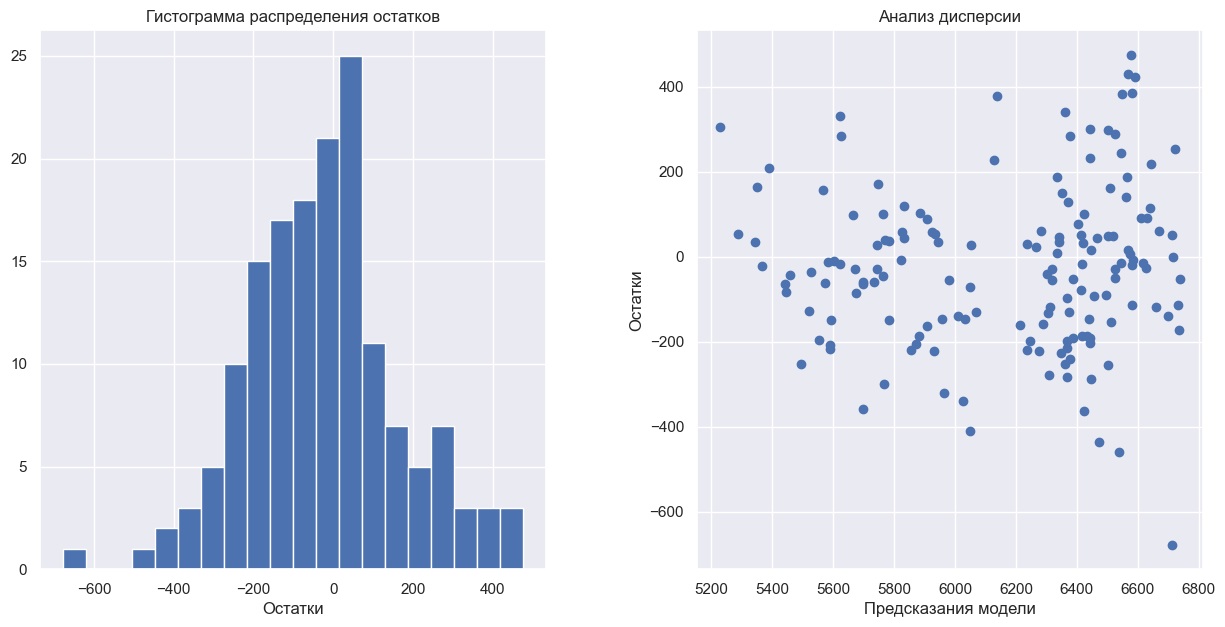

In [80]:
num_col_names = ['эке^2', 'сырой_протеин_г']
cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'возраст', 'класс_спо']
col_X = ['id', 'удой_кг', 'эке', 'спо', 'жирность_%', 'белок_%', 'вкус_молока']
data = ferma_main
graf_r2(r2_func)

**Для второй модели значение R<sup>2</sup> повысилось, гистограмма также показывает сдвиг вправо, но график дисперсии практически не изменился.**

### 5.3 Добавление в данные нового признака 'имя_папы' и обучение на них третьей модели LinearRegression

У нас уже есть датасет `ferma_main_dad`. Будем работать с ним.

In [81]:
ferma_main_dad['класс_спо'] = ferma_main_dad['спо'].apply(lambda x: 1 if x > 0.9 else 0)
ferma_main_dad['эке^2'] = ferma_main_dad['эке']**2

D:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


R2 LinearRegression = 0.8247542745210407


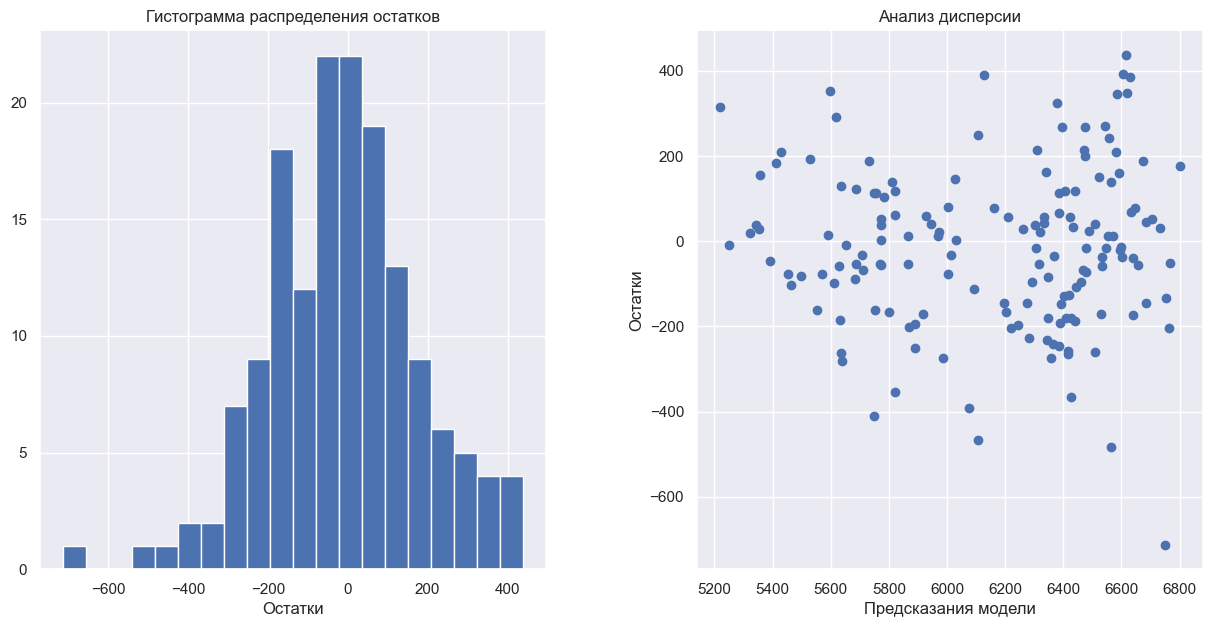

In [82]:
num_col_names = ['эке^2', 'сырой_протеин_г']
cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'возраст', 'класс_спо', 'имя_папы']
col_X = ['id', 'удой_кг', 'эке', 'спо', 'жирность_%', 'белок_%', 'вкус_молока']
data = ferma_main_dad
graf_r2(r2_func)

**Третья модель показывает результаты лучше, чем первая и вторая. R<sup>2</sup> выше, гистограмма не имеет сдвигов, а чередование маленьких и больших дисперсий остатков не так сильно выражено.**

### 5.4 Сравнение качества трёх моделей линейной регрессии, сопоставление их R<sup>2</sup> и остатков

Наихудший результат из трех построенных моделей показала первая модель, несмотря на достаточно высокое значение R<sup>2</sup>. Наилучший результат показала третья модель, хотя анализ дисперсии показывает не самые качественные результаты.

### 5.5 Оценка качества каждой модели по трём метрикам: MSE, MAE, RMSE. Расчет доверительного интервала

In [83]:
def mse_mae_rmse(func,n):   
    r2_func(data, col_X, cat_col_names, num_col_names)
    
    # получение значения MSE
    mse = mean_squared_error(predictions, y_test)
    print('MSE для модели № ',n,':', round(mse,2))
    
    # получение значения RMSE
    rmse = mean_squared_error(predictions, y_test, squared=False)
    
    print('RMSE для модели № ',n,':',round(rmse,2))
    
    # рассчитайте MAE для линейной регрессии
    mae = mean_absolute_error(predictions, y_test)
    
    print('MAE для модели № ',n,':',round(mae,2))

num_col_names = ['эке', 'сырой_протеин_г', 'спо']
cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'возраст']
col_X = ['id', 'удой_кг', 'жирность_%', 'белок_%', 'вкус_молока']
data = ferma_main
mse_mae_rmse(r2_func,1)

MSE для модели №  1 : 43887.02
RMSE для модели №  1 : 209.49
MAE для модели №  1 : 164.24


D:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [84]:
num_col_names = ['эке^2', 'сырой_протеин_г']
cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'возраст', 'класс_спо']
col_X = ['id', 'удой_кг', 'эке', 'спо', 'жирность_%', 'белок_%', 'вкус_молока']
data = ferma_main
mse_mae_rmse(r2_func,2)

MSE для модели №  2 : 37030.91
RMSE для модели №  2 : 192.43
MAE для модели №  2 : 149.04


D:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [85]:
num_col_names = ['эке^2', 'сырой_протеин_г']
cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'возраст', 'класс_спо', 'имя_папы']
col_X = ['id', 'удой_кг', 'эке', 'спо', 'жирность_%', 'белок_%', 'вкус_молока']
data = ferma_main_dad
mse_mae_rmse(r2_func,3)

MSE для модели №  3 : 35673.89
RMSE для модели №  3 : 188.88
MAE для модели №  3 : 146.16


D:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


**Показатели MSE, RMSE и MAE также демонстрируют превосходство третьей модели, т.к. демонстрируют наименьшие значения.**

Укажем доверительный интервал прогноза третьей модели. Для этого рассчитаем квантили ошибки модели на тренировочных данных.

**95-процентный доверительный интервал** — это вычисленный промежуток, в котором по предположению находится среднее значение признака в генеральной совокупности. Если многократно проводить эксперимент, то среднее значение признака в генеральной совокупности будет попадать в найденный доверительный интервал в 95% случаев.

In [86]:
num_col_names = ['эке^2', 'сырой_протеин_г']
cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'возраст', 'класс_спо', 'имя_папы']
col_X = ['id', 'удой_кг', 'эке', 'спо', 'жирность_%', 'белок_%', 'вкус_молока']
r2_func(ferma_main_dad, col_X, cat_col_names, num_col_names)
confidence_interval_025 = np.quantile(predictions,0.025)
confidence_interval_975 = np.quantile(predictions,0.975)
print('С вероятностью 0.95 можно ожидать удой от коров на ферме в интервале :',\
      round(confidence_interval_025,2), 'кг -',round(confidence_interval_975,2),' кг')

С вероятностью 0.95 можно ожидать удой от коров на ферме в интервале : 5351.32 кг - 6749.08  кг


D:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


### 5.6 Прогноз удоя коров, предполагаемых к приобретению

С помощью лучшей модели спрогнозируем удой коров, которых фермер хочет купить. Данные о них находятся в датасете `cow_buy.csv`.

Добавим недостающие признаки `эке`, `сырой_протеин_г` и `спо`: возьмем из датасета `ferma_main.csv` средние значения каждого из признаков и увеличим их на 5%. Выполним подготовку данных, аналогичную той, которую делали для тренировочной выборки.

In [87]:
cow_buy['эке^2'] = (ferma_main['эке'].mean()*1.05)**2
cow_buy['спо'] = ferma_main['спо'].mean()*1.05
cow_buy['сырой_протеин_г'] = ferma_main['сырой_протеин_г'].mean()*1.05
cow_buy['класс_спо'] = cow_buy['спо'].apply(lambda x: 1 if x > 0.91 else 0)

In [88]:
X_train = ferma_main_dad.drop(['id', 'удой_кг', 'спо', 'жирность_%', 'белок_%', 'вкус_молока', 'эке'], axis=1)
y_train = ferma_main_dad['удой_кг']


cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'возраст', 'имя_папы','класс_спо']
num_col_names = ['сырой_протеин_г', 'эке^2']

## подготовка признаков (масштабирование и кодирование)

encoder = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])

encoder_col_names = encoder.get_feature_names()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)

# инициализируйте модель линейной регрессии
model_lr  = LinearRegression()

# обучите модель на тренировочных данных
model_lr.fit(X_train, y_train)

X_pred = cow_buy.drop(['текущая_жирность_%', 'текущий_уровень_белок_%','спо'], axis=1)

X_pred_ohe = encoder.transform(X_pred[cat_col_names])

encoder_col_names = encoder.get_feature_names()

X_pred_scaled = scaler.transform(X_pred[num_col_names])

X_pred_ohe = pd.DataFrame(X_pred_ohe, columns=encoder_col_names)

X_pred_scaled = pd.DataFrame(X_pred_scaled, columns=num_col_names)

X_pred = pd.concat([X_pred_ohe, X_pred_scaled], axis=1)

# получите предсказания модели на тестовых данных 
# сохраните результат в переменную predictions
predictions = model_lr.predict(X_pred)
pred_data = pd.DataFrame(predictions, columns=['удой_кг'])
cow_buy_pred = pd.concat([cow_buy.reset_index(drop=True),pred_data.reset_index(drop=True)], axis=1)
cow_buy_pred['эке'] = cow_buy_pred['эке^2']**0.5
display(cow_buy_pred.sort_values(by = 'удой_кг', ascending = False))  

D:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)
D:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


,порода,тип_пастбища,порода_папы_быка,имя_папы,текущая_жирность_%,текущий_уровень_белок_%,возраст,эке^2,спо,сырой_протеин_г,класс_спо,удой_кг,эке
3,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,233.361138,0.958744,2019.947532,1,6593.677429,15.276162
12,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.065,более_2_лет,233.361138,0.958744,2019.947532,1,6593.677429,15.276162
9,РефлешнСоверинг,Равнинное,Соверин,Геркулес,3.73,3.073,более_2_лет,233.361138,0.958744,2019.947532,1,6589.281700,15.276162
0,Вис Бик Айдиал,Холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,233.361138,0.958744,2019.947532,1,6583.691248,15.276162
10,Вис Бик Айдиал,Холмистое,Айдиал,Геркулес,3.68,3.046,более_2_лет,233.361138,0.958744,2019.947532,1,6583.691248,15.276162
4,РефлешнСоверинг,Равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,233.361138,0.958744,2019.947532,1,6545.136866,15.276162
6,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,233.361138,0.958744,2019.947532,1,6531.868301,15.276162
15,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.34,3.069,более_2_лет,233.361138,0.958744,2019.947532,1,6531.868301,15.276162
7,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,233.361138,0.958744,2019.947532,1,6375.747238,15.276162
5,РефлешнСоверинг,Равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет,233.361138,0.958744,2019.947532,1,6371.351509,15.276162


<div style="border:solid green 2px; padding: 20px">
Вывод: На шаге 5 были обучены три модели. Наилучшие результаты показала модель №3 (R<sup>2</sup> LinearRegression = 0,825, MSE = 35673,89, RMSE = 188.88, MAE = 146,16).
    
С вероятностью 0.95 можно ожидать удой от коров на ферме в интервале : 5351.32 кг - 6749.08  кг
    
Были проанализированы зависимости показателя `удой_кг` и прочих количественных признаков в разрезе категориальных признаков.
    
Получен прогнозный удой для рассматриваемой к покупке группы лактационных коров.

## Шаг 6. Обучение модели логистической регрессии

### 6.1 Подготовка данныx датасета 'ferma_main.csv' и обучите на них модель LogisticRegression

Используем в качестве целевого признак `вкус молока`. Оценим качество модели на тестовой выборке: рассчитаем метрики `accuracy`, `recall`, `precision`.

In [89]:
ferma_main_dad['вкус_молока'] = ferma_main_dad['вкус_молока'].apply(lambda x: 1 if x == 'вкусно' else 0)

In [90]:
def log_reg(data, col_X, cat_col_names, num_col_names):
    
    global y_pred, y_test, clf, X_test, X_test_scaled
    
    X = data.drop(col_X, axis=1)
    y = data['вкус_молока']

    # разбивка данных на тренировочную и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, 
        y, 
        random_state=RANDOM_STATE)

    cat_col_names = cat_col_names
    num_col_names = num_col_names

    ## подготовка признаков (масштабирование и кодирование)

    encoder = OneHotEncoder(drop='first', sparse=False)
    X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
    X_test_ohe = encoder.transform(X_test[cat_col_names])

    encoder_col_names = encoder.get_feature_names()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[num_col_names])
    X_test_scaled = scaler.transform(X_test[num_col_names])

    X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
    X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

    X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
    X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

    # создание объекта для работы с моделью
    clf = LogisticRegression()

    # обучение модели на данных
    clf = clf.fit(X_train, y_train)

    # получение прогнозных меток классов
    y_pred = clf.predict(X_test)

In [91]:
def sns_log(func):    
    log_reg(data, col_X, cat_col_names, num_col_names)
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(9, 9))
    sns.heatmap(np.eye(2), annot=cm, fmt='d', annot_kws={'size': 15},
                cmap='Greens', cbar=False,
                yticklabels=['False','True'], xticklabels=['False','True'], ax=ax)
    ax.tick_params(labelsize=15, length=0)

    ax.set_title('Матрица ошибок', size=24, pad=20)
    ax.set_xlabel('Предсказанные значения', size=15)
    ax.set_ylabel('Истинные значения', size=15)

    additional_num = [format(cm[0][0]/len(y_test), ".0%"),format(cm[0][1]/len(y_test), ".0%"),\
          format(cm[1][0]/len(y_test), ".0%"),format(cm[1][1]/len(y_test), ".0%")]
    additional_texts = ['(Истинно-отрицательные)', '(Ложно-положительные)', '(Ложно-отрицательные)', '(Истинно-положительные)']
    for text_elt, additional_text,additional_num in zip(ax.texts, additional_texts,additional_num):
        ax.text(*text_elt.get_position(), '\n'+additional_num+'\n' + additional_text, color=text_elt.get_color(),
                ha='center', va='top', size=15)
    
    plt.tight_layout()
    plt.show()
    
    acc = accuracy_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
        
    print('accuracy = ',acc)
    print('recall = ',recall)
    print('precision = ',precision)

D:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


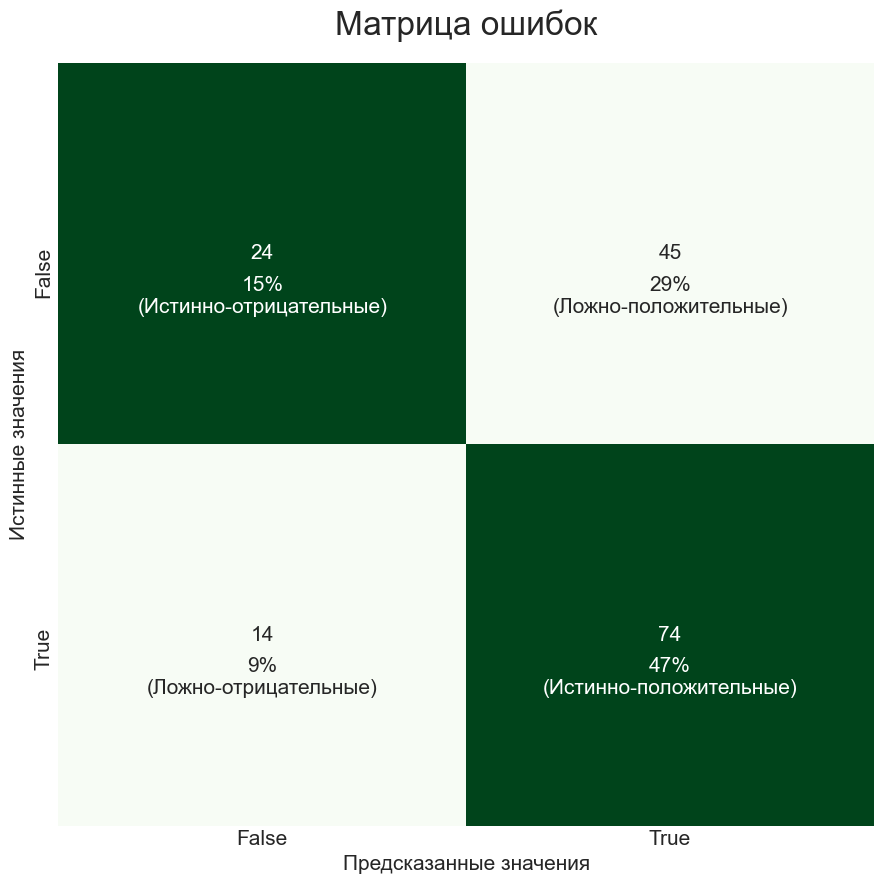

accuracy =  0.6242038216560509
recall =  0.8409090909090909
precision =  0.6218487394957983


In [92]:
num_col_names = ['эке', 'сырой_протеин_г']
cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'класс_спо', 'возраст']
col_X = ['id', 'спо', 'вкус_молока', 'удой_кг', 'жирность_%', 'белок_%', 'эке^2','имя_папы']
data = ferma_main_dad
sns_log(log_reg)

**Показатели жирности и белка были удалены, т.к. у планируемых к покупке коров эти показатели другие (ввиду иного корма).**

Критичнее всего при покупке коров ошибка первого рода (45 значений). Главное для заказчика — вкусное молоко, поэтому главное не ошибится с проставлением значения 'вкусно' вместо 'не вкусно'. С учётом метрик recall и precision наиболее важная из них `precision`.

### 6.2 Сведение критичной ошибки к нулю

In [93]:
def pre_proba(func):
    
    global df
    
    log_reg(data, col_X, cat_col_names, num_col_names)
    y_proba = clf.predict_proba(X_test)[:,1]
    df = pd.DataFrame(zip(y_test, y_pred, y_proba), \
                      columns = ['y_test', 'y_pred','y_proba']).sort_values(by='y_proba',ascending=False)
    display(df)

In [94]:
num_col_names = ['эке', 'сырой_протеин_г']
cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'класс_спо', 'возраст']
col_X = ['id', 'спо', 'вкус_молока', 'удой_кг', 'жирность_%', 'белок_%', 'эке^2','имя_папы']
data = ferma_main_dad
pre_proba(log_reg)

D:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


,y_test,y_pred,y_proba
146,1,1,0.850243
85,1,1,0.835495
152,1,1,0.825731
13,1,1,0.822052
114,1,1,0.820980
...,...,...,...
23,1,0,0.336269
144,0,0,0.334551
119,0,0,0.329070
84,0,0,0.278999


In [95]:
thresholds = [round(i,3) for i in np.linspace(0,1,num = 1000,endpoint=False)]

columns = []

for i in thresholds:
    columns.append('y_pred_'+str(i))
    df['y_pred_'+str(i)] = df['y_proba'].apply(lambda x: 1 if x>= i else 0)

display(df.head())

C:\Users\Татьяна\AppData\Local\Temp\ipykernel_4292\610213661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['y_pred_'+str(i)] = df['y_proba'].apply(lambda x: 1 if x>= i else 0)
C:\Users\Татьяна\AppData\Local\Temp\ipykernel_4292\610213661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['y_pred_'+str(i)] = df['y_proba'].apply(lambda x: 1 if x>= i else 0)
C:\Users\Татьяна\AppData\Local\Temp\ipykernel_4292\610213661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame

C:\Users\Татьяна\AppData\Local\Temp\ipykernel_4292\610213661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['y_pred_'+str(i)] = df['y_proba'].apply(lambda x: 1 if x>= i else 0)
C:\Users\Татьяна\AppData\Local\Temp\ipykernel_4292\610213661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['y_pred_'+str(i)] = df['y_proba'].apply(lambda x: 1 if x>= i else 0)
C:\Users\Татьяна\AppData\Local\Temp\ipykernel_4292\610213661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame

C:\Users\Татьяна\AppData\Local\Temp\ipykernel_4292\610213661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['y_pred_'+str(i)] = df['y_proba'].apply(lambda x: 1 if x>= i else 0)
C:\Users\Татьяна\AppData\Local\Temp\ipykernel_4292\610213661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['y_pred_'+str(i)] = df['y_proba'].apply(lambda x: 1 if x>= i else 0)
C:\Users\Татьяна\AppData\Local\Temp\ipykernel_4292\610213661.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame

,y_test,y_pred,y_proba,y_pred_0.0,y_pred_0.001,y_pred_0.002,y_pred_0.003,y_pred_0.004,y_pred_0.005,y_pred_0.006,...,y_pred_0.99,y_pred_0.991,y_pred_0.992,y_pred_0.993,y_pred_0.994,y_pred_0.995,y_pred_0.996,y_pred_0.997,y_pred_0.998,y_pred_0.999
146,1,1,0.850243,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
85,1,1,0.835495,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
152,1,1,0.825731,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
13,1,1,0.822052,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
114,1,1,0.820980,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [96]:
for i in thresholds:
    cm = confusion_matrix(df['y_test'], df['y_pred_'+str(i)])
    if cm[0][1] == 0:
        print('Порог = ',i ,'Precision = ', round(precision_score(df['y_test'], df['y_pred_'+str(i)]), 2), 'TP =', cm[1][1])
        porog=i
        break

Порог =  0.816 Precision =  1.0 TP = 5


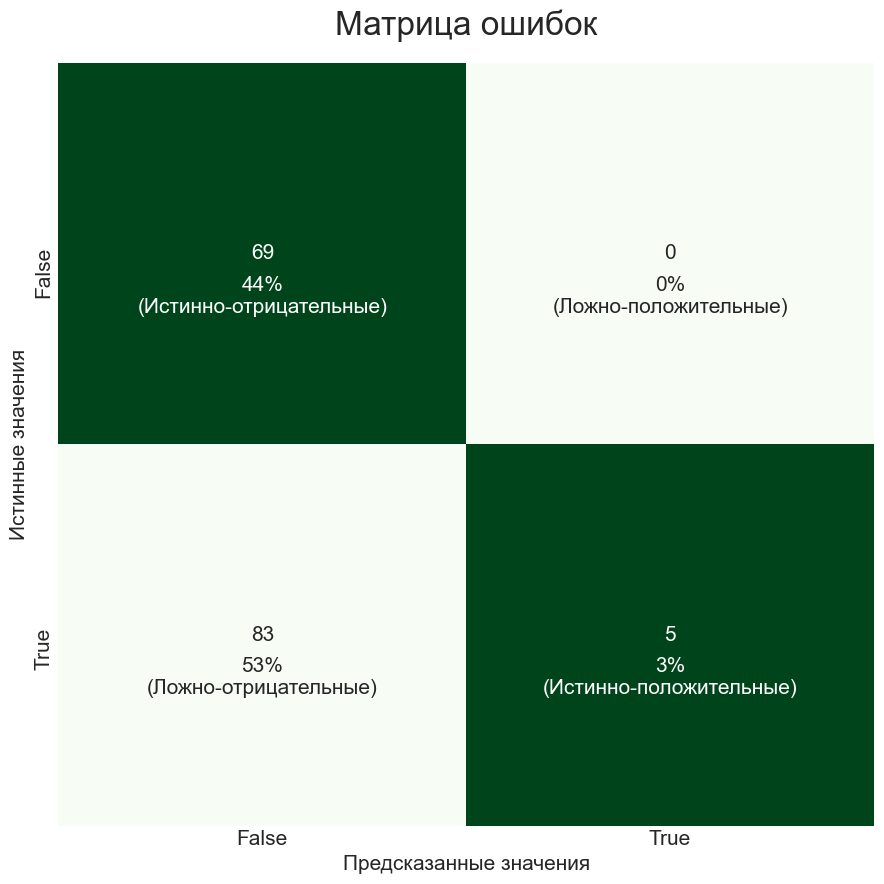

accuracy =  0.6242038216560509
recall =  0.8409090909090909
precision =  0.6218487394957983


In [97]:
fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(np.eye(2), annot=cm, fmt='d', annot_kws={'size': 15},
                cmap='Greens', cbar=False,
                yticklabels=['False','True'], xticklabels=['False','True'], ax=ax)
ax.tick_params(labelsize=15, length=0)

ax.set_title('Матрица ошибок', size=24, pad=20)
ax.set_xlabel('Предсказанные значения', size=15)
ax.set_ylabel('Истинные значения', size=15)

additional_num = [format(cm[0][0]/len(y_test), ".0%"),format(cm[0][1]/len(y_test), ".0%"),\
          format(cm[1][0]/len(y_test), ".0%"),format(cm[1][1]/len(y_test), ".0%")]
additional_texts = ['(Истинно-отрицательные)', '(Ложно-положительные)', '(Ложно-отрицательные)', '(Истинно-положительные)']
for text_elt, additional_text,additional_num in zip(ax.texts, additional_texts,additional_num):
        ax.text(*text_elt.get_position(), '\n'+additional_num+'\n' + additional_text, color=text_elt.get_color(),
                ha='center', va='top', size=15)
    
plt.tight_layout()
plt.show()
    
acc = accuracy_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
        
print('accuracy = ',acc)
print('recall = ',recall)
print('precision = ',precision)

In [98]:
X_train = ferma_main_dad.drop(['id', 'спо', 'вкус_молока', 'удой_кг', 'жирность_%', 'белок_%', 'эке^2','имя_папы'], axis=1)
y_train = ferma_main_dad['вкус_молока']

cat_col_names = ['порода', 'тип_пастбища', 'порода_папы_быка', 'класс_спо', 'возраст']
num_col_names = ['эке', 'сырой_протеин_г']

## подготовка признаков (масштабирование и кодирование)

encoder = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])

encoder_col_names = encoder.get_feature_names()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)

# создание объекта для работы с моделью
clf = LogisticRegression()

# обучение модели на данных
clf = clf.fit(X_train, y_train)

X_pred = cow_buy_pred.drop(['текущий_уровень_белок_%', 'спо', 'текущая_жирность_%','удой_кг','эке^2','имя_папы'], axis=1)


X_pred_ohe = encoder.transform(X_pred[cat_col_names])

encoder_col_names = encoder.get_feature_names()


X_pred_scaled = scaler.transform(X_pred[num_col_names])

X_pred_ohe = pd.DataFrame(X_pred_ohe, columns=encoder_col_names)

X_pred_scaled = pd.DataFrame(X_pred_scaled, columns=num_col_names)

X_pred = pd.concat([X_pred_ohe, X_pred_scaled], axis=1)

y_pred = clf.predict_proba(X_pred)[:,1]

cow_buy_pred['y_pred'] = y_pred

cow_buy_pred['вкус_молока'] = cow_buy_pred['y_pred'].apply(lambda x: 'вкусно' if x > porog else 'не вкусно')      

display(cow_buy_pred)

D:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)
D:\Anaconda\envs\practicum\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


,порода,тип_пастбища,порода_папы_быка,имя_папы,текущая_жирность_%,текущий_уровень_белок_%,возраст,эке^2,спо,сырой_протеин_г,класс_спо,удой_кг,эке,y_pred,вкус_молока
0,Вис Бик Айдиал,Холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,233.361138,0.958744,2019.947532,1,6583.691248,15.276162,0.723069,не вкусно
1,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,233.361138,0.958744,2019.947532,1,6313.938111,15.276162,0.522076,не вкусно
2,РефлешнСоверинг,Равнинное,Соверин,Барин,3.59,3.074,более_2_лет,233.361138,0.958744,2019.947532,1,6301.240734,15.276162,0.497019,не вкусно
3,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,233.361138,0.958744,2019.947532,1,6593.677429,15.276162,0.690826,не вкусно
4,РефлешнСоверинг,Равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,233.361138,0.958744,2019.947532,1,6545.136866,15.276162,0.519808,не вкусно
5,РефлешнСоверинг,Равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет,233.361138,0.958744,2019.947532,1,6371.351509,15.276162,0.483159,не вкусно
6,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,233.361138,0.958744,2019.947532,1,6531.868301,15.276162,0.535894,не вкусно
7,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,233.361138,0.958744,2019.947532,1,6375.747238,15.276162,0.678857,не вкусно
8,Вис Бик Айдиал,Холмистое,Соверин,Соловчик,3.73,3.055,более_2_лет,233.361138,0.958744,2019.947532,1,6351.885016,15.276162,0.704441,не вкусно
9,РефлешнСоверинг,Равнинное,Соверин,Геркулес,3.73,3.073,более_2_лет,233.361138,0.958744,2019.947532,1,6589.281700,15.276162,0.497019,не вкусно


<div style="border:solid green 2px; padding: 20px">
    Вывод: На шаге 6 была обучена логистическая модель. Показатель `вкус_молока` был переведен в категориальный признак. 
Ни одна корова не подходит под нужные критерии для покупки. Главное для заказчика — вкусное молоко, поэтому главное не ошибится с проставлением значения 'вкусно' вместо 'не вкусно'. Наиболее важная метрика - precision.

## Шаг 7. Итоговые выводы

<div style="border:solid green 2px; padding: 20px">
Вывод по итогам проекта:
    
- в рамках изучения данных наименования столбцов были заменены во всех датасетах.
    
- на этапе исследования данных были изучены категориальные и количественные признаки. Возник вопрос в отношении несоответствия породы папы-быка и имени. Они разные. При проведении реального проекта этот вопрос можно было бы уточнить. Удалены данные о корове со слишком большим показателем удоя. Здесь можно было бы тоже уточнить у заказчика истинные данные.
    
- на этапе корреляционного анализа отмечено, что наибольшая корреляция у показателя `удой_кг` с показателями `жирность_%`, `спо` и `эке`. Но показатели `жирность_%` лучше при прогнозировании не использовать. Для поставщика это будет заведомо ложная информация. Данные показатели для предполагаемых к покупке коров будут другими из-за изменения корма при передаче новому хозяину. Наблюдается линейная связь между показателями `удой_кг` и `эке`. Между показателем удой_кг и остальными входными признаками скорее нелинейная связь, но новые данные вводить не надо, т.к. основные представленные входные признаки уже представляют большинство показателей, от которых зависит качество удоя и на их основании можно провести дальнейшую работу. Мультиколлинеарность между входными признаками не наблюдается.
    
- на этапе регрессии были обучены три модели для дальнейшего прогнозирования показателя `удой_кг`. Наиболее подходящими данными для обучения признаны входящие признаки (`эке`, `сырой_протеин_г`, `спо`, `порода`, `тип_пастбища`, `порода_папы_быка` и `возраст`). Эти признаки в первую очередь характеризуют питание и содержание коров. Остальные признаки являются уже последствиями. Одна из трех моделей показала наилучший результат. Данные датасета с планируемыми к приобретению коровами были изменены, чтобы приблизить их к показателям содержания уже имеющихся у заказчика коров. Было бы хорошо спрогнозировать и показатели белка и жирности по новым данным. Но пока этого не производилось. Прогноз удоя у коров, которые предполагаются к покупке, оказался хорошим (более 6000 кг). В датасет добавлен показатель `эке` для дальнейших исследований.
    
- на этапе классификации была обучена модель 'LogisticRegression'. В качестве целевого признака использован показатель `вкус_молока`. Главное для заказчика — вкусное молоко, поэтому главное не ошибится с проставлением значения 'вкусно' вместо 'не вкусно'. С учётом метрик наиболее важная из них `precision`.

По итогам, ни одна корова не подходит под нужные критерии для покупки. Были улучшены показатели `эке` (возведен в квадрат) и `спо` (переведен в бинарный признак). Крайне необходимо разобраться в данных по породе папы-быка. Этот фактор может серьезно влиять на показатели моделей. Для улучшения модели было бы найти зависимость между показателями после приобретения, т.к. на момент покупки невозможно использовать такие данные как жирность и белок (они фактически не отражают ситуацию, ввиду того, что это данные в результате питания коров в условиях продавца). Эти данные достаточно важны. Можно было бы вместо показателя имени папы-быка ввести более подробные данные о быке-производителе. На данный момент по своей сути (при условии, что быков производителей только 4) порода является подфактором для имени папы-быка. Но и здесь, как было описано выше, если серьезные вопросы. Наиболее же показательными являются показатели питания и содержания. 
